In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
# os.chdir("..")
# import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [2]:
step1_map = pd.read_csv("../../../output/ChopTFs_pipeline/step1.csv")
step1_map = step1_map[["AD", "AD_end", "AD_BC", "RPTR_BC"]].drop_duplicates()
step1_map

,AD,AD_end,AD_BC,RPTR_BC
0,GTTGAGAAATTGCAATTCTTCTTGTTGTCTTATATTTCTGTTATGA...,AGGTGTTGATTTGATTAATGAATTGTGTCAAGGTTGTATT,CCAAATGACTA,GCTTGTACACATAC
1,TTGCCTAAATATTCTTCTTTGGATATTGATGATTTGTGTTCTGAAT...,GATTGTTGTTAAAGCTAGAGATTTGCAATCTGCTTTGGTT,ACTGAGCTAGA,CGCTGATGACCTAA
2,ACTAATATTAAACCATCTCCATCTTCTTCTGTTGATAATTTGAATG...,TGTTAATTCTTTGAATGATGAGTTCTGGACTGATTTGTTT,CTTCACAGGCC,TGCCCAGTGGACGC
3,TCTGCTCCAATGCCAATTAATCAAACTCAGAAGAAATTGTCTGATG...,GTCTAATTCTAATGATGTCTTGAATAATACTCCAAATTCT,TTCGACTCTCC,TAAATCTTGTAGTG
4,GATTCTAATCCAAATACTAATTTGGAAGATTCTTTGTTCTTTGATC...,TAATGGTCAAGGTTCTAATAATGGTAGACAAGCTTCTAAA,TAAACAGAGAC,CAGAAGTCTTTAAC
...,...,...,...,...
404383,AGAGAAACTTCTCAAACTGCTATGTTGACTGATCATGAAGATAATA...,TGCTGCTTCTTCTCCAAGATTGCCATTGTCTAGATTGAAT,CCCCGCTTTCT,TACCCTCGCGAAGC
404384,GTTGAAAGGATTCCAGATTCTGAATTGCAACATCATAAGAGAGTTG...,TATTCAAGAAGGTGAAGATATTAATCCAACTGAGTTCTTG,TCCCTTTACCG,GAGAGAAAAGGAGT
404385,AGAGTTACTGACTTTGGTGGTAAATCTTTGTCTATGGGATTCTCTT...,TTATGCTTTGAAAGGTTGGTATGATTCTAAAGGTAGAAAT,AATAATTCGTT,AAACTCTCCGCCTT
404386,GATTCTGAATTGCAACATCATAAGAGAGTTGAAGCTACTGAAGAAG...,AGATATTAATCCAACTGAGTTCTTGAAGAATTATAATGTT,AGAGCCTTGCA,CTTCGACTGTCTAG


In [3]:
def read_and_label(files, label):
    """
    Reads TSV files, adds a descriptive 'file_base' column.

    Parameters:
        files: list of file paths
        label: string, e.g., "AD_simple" or "RPTR_directional"

    Returns:
        DataFrame with added 'file_base' column
    """
    dfs = []
    for f in tqdm.tqdm(files):
        df = pd.read_csv(f, sep="\t")
        # descriptive file_base: <label>_<original_file_name_without_ext>
        df["file_base"] = f"{label}_{os.path.splitext(os.path.basename(f))[0]}"
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Getting all AD counts

In [4]:
# Find simple and directional AD files
simple_AD_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*AD*/*simple*")
directional_AD_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*AD*/*directional*")

In [5]:
# Read files with descriptive file_base
simple_AD_df = read_and_label(simple_AD_files, label="AD_simple")
directional_AD_df = read_and_label(directional_AD_files, label="AD_directional")

100%|██████████| 30/30 [00:12<00:00,  2.44it/s]


In [6]:
simple_AD_df["gene"] = simple_AD_df["AD_end"] + simple_AD_df["AD_BC"]
simple_AD_df["rep"] = simple_AD_df["file_base"].str.extract(r'AD_(\d+)_').astype(int)
simple_AD_df["time"] = simple_AD_df["file_base"].str.extract(r'AD_\d+_(\d+)').astype(int)
simple_AD_df

,AD_end,AD_BC,count,file_base,gene,rep,time
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50
...,...,...,...,...,...,...,...
9978655,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTT,AGAGTACGTTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTTAGAGTA...,3,60
9978656,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACG,CTCAAGGCCAC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACGCTCAAG...,3,60
9978657,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAAT,ATCAAAGTTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAATATCAAA...,3,60
9978658,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTAT,TCGGCTATTAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTATTCGGCT...,3,60


In [7]:
directional_AD_df["rep"] = directional_AD_df["file_base"].str.extract(r'AD_(\d+)_').astype(int)
directional_AD_df["time"] = directional_AD_df["file_base"].str.extract(r'AD_\d+_(\d+)').astype(int)
directional_AD_df

,gene,count,file_base,rep,time
0,AAAAAAAAAAACTACTGTCTTGCAACCAGCTTCTCATTCTCCCCCC...,1,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,4,50
1,AAAAAAAAAAACTACTGTCTTGCAACCAGCTTCTCATTCTCGAGAC...,1,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,4,50
2,AAAAAAAAAACAAAAAAAACAACAACAACAACAACCACAAAACCCC...,1,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,4,50
3,AAAAAAAAAAGCTACTGTCTTGCAACCAGCTTCTCATTCTCCCCCC...,4,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,4,50
4,AAAAAAAAAAGCTACTGTCTTGCAACCAGCTTCTCATTCTCTCCCG...,3,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,4,50
...,...,...,...,...,...
9978655,TTTTTTTTTGTGGGTTGTCGGGGGTGTTGGGGTTGAGTAAATGAGT...,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,3,60
9978656,TTTTTTTTTTATTTACTGTGGTGGTGAATAGTCCAATCCGGGCAAA...,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,3,60
9978657,TTTTTTTTTTGTGTACGTTGGTGGTGAATAAGCCACTCTAGGCAAA...,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,3,60
9978658,TTTTTTTTTTTCTGGTGATGCTACTAATTTGATTGGTGTTGTGAAA...,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,3,60


In [8]:
# Merge on AD_end, AD_BC, and descriptive file_base
merged_AD_df = pd.merge(
    simple_AD_df,
    directional_AD_df,
    on=["gene", "rep", "time"],
    suffixes=("_simple", "_directional")
)

merged_AD_df.head()

,AD_end,AD_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50,21126,AD_directional_AD_4_50_S29_R1_001_fastp_direct...
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50,18062,AD_directional_AD_4_50_S29_R1_001_fastp_direct...
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50,15886,AD_directional_AD_4_50_S29_R1_001_fastp_direct...
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50,15291,AD_directional_AD_4_50_S29_R1_001_fastp_direct...
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50,12912,AD_directional_AD_4_50_S29_R1_001_fastp_direct...


In [9]:
merged_AD_df["count_diff"] = merged_AD_df["count_simple"] - merged_AD_df["count_directional"]
merged_AD_df

,AD_end,AD_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50,21126,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,1098
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50,18062,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,824
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50,15886,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,639
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50,15291,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,643
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50,12912,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,478
...,...,...,...,...,...,...,...,...,...,...
9978655,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTT,AGAGTACGTTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTTAGAGTA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978656,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACG,CTCAAGGCCAC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACGCTCAAG...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978657,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAAT,ATCAAAGTTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAATATCAAA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978658,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTAT,TCGGCTATTAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTATTCGGCT...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0


Text(0, 0.5, 'Complex UMI Count')

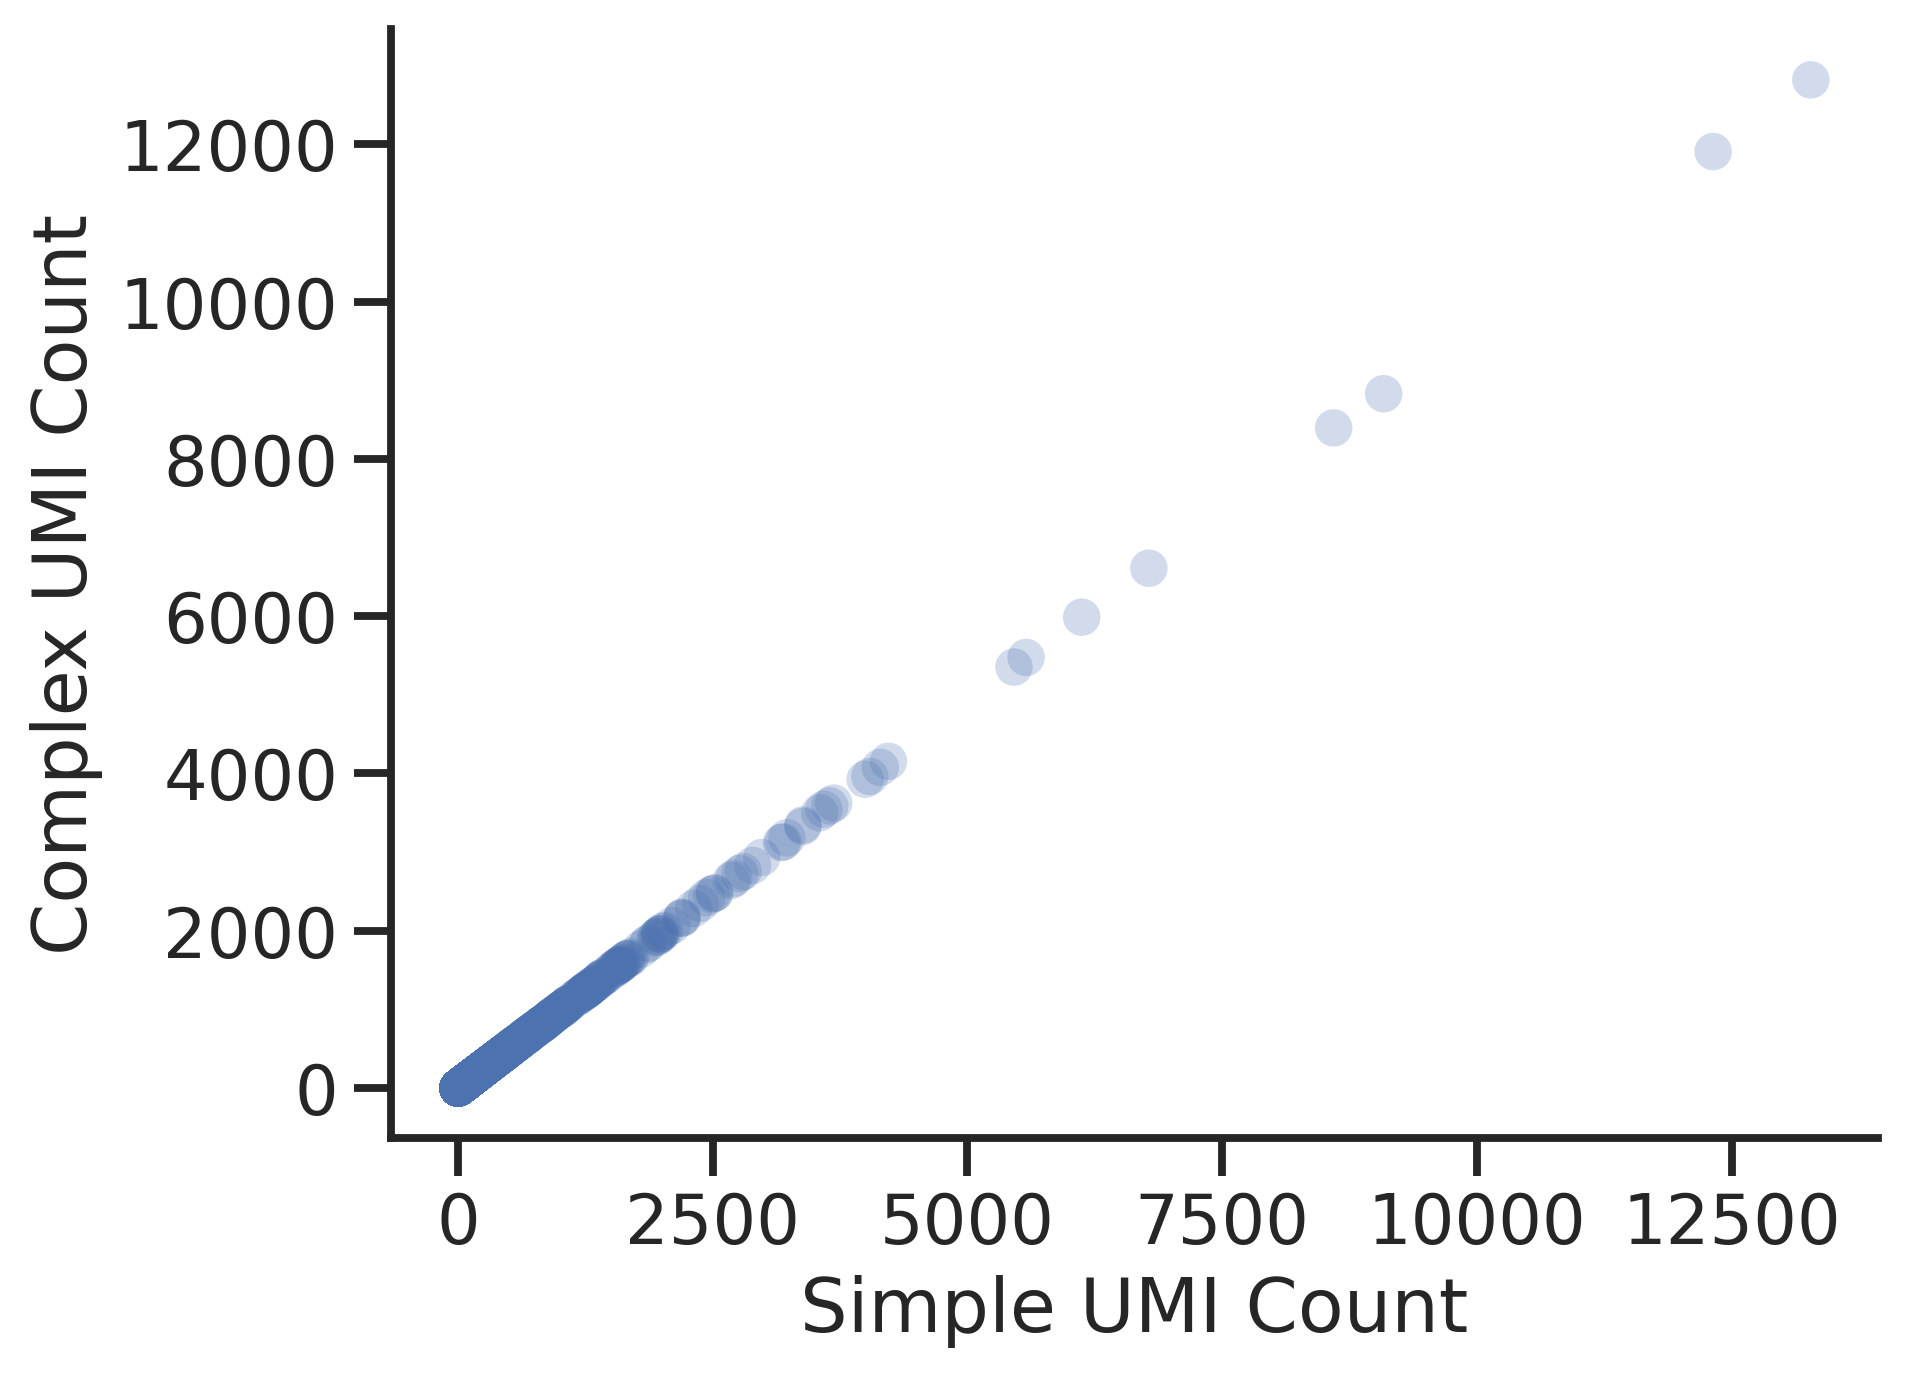

In [10]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = merged_AD_df.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

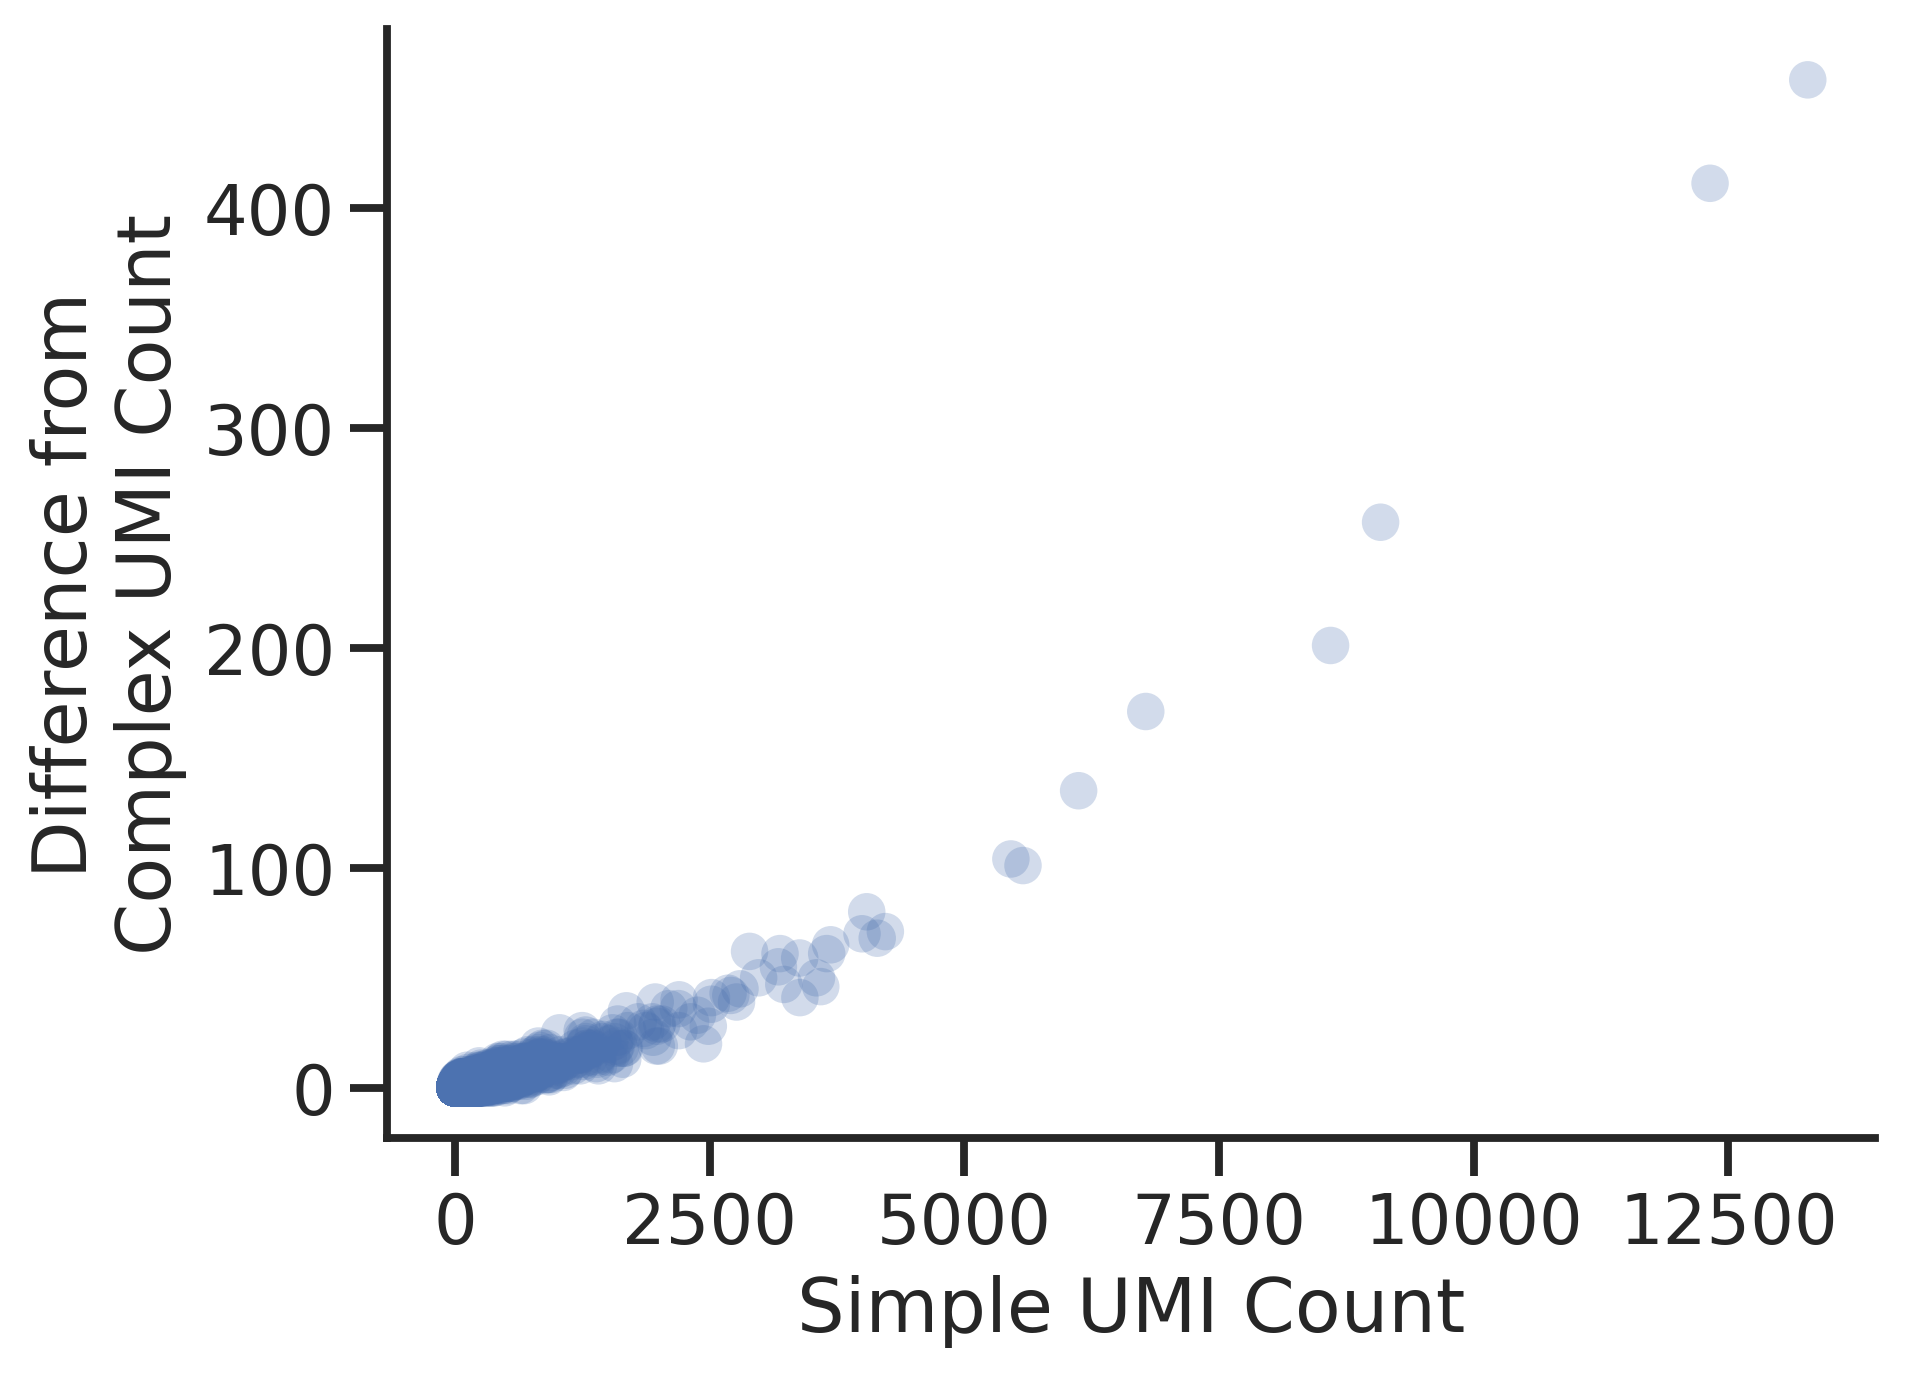

In [11]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = merged_AD_df.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

In [12]:
merged_AD_df.to_csv("../../../output/ChopTFs_pipeline/AD_trebl_experiment_results.csv")

# Getting all RT counts

In [13]:
# Find simple and directional AD files
simple_RT_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*RP*/*simple*")
directional_RT_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*RP*/*directional*")

In [14]:
# Read files with descriptive file_base
simple_RT_df = read_and_label(simple_RT_files, label="RT_simple")
directional_RT_df = read_and_label(directional_RT_files, label="RT_directional")

100%|██████████| 30/30 [00:09<00:00,  3.22it/s]


In [15]:
simple_RT_df

,RPTR_BC,count,file_base
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...
...,...,...,...
6856548,GGAGGTTACGTCTC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...
6856549,GAGTGTTGAATATA,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...
6856550,TACCGAGCTAAATT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...
6856551,ACAAAACCTAAGGG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...


In [16]:
simple_RT_df["gene"] = simple_RT_df["RPTR_BC"]
simple_RT_df["rep"] = simple_RT_df["file_base"].str.extract(r'RP_(\d+)_').astype(int)
simple_RT_df["time"] = simple_RT_df["file_base"].str.extract(r'RP_\d+_(\d+)').astype(int)
simple_RT_df

,RPTR_BC,count,file_base,gene,rep,time
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGGTAAGGAGTCTA,4,40
...,...,...,...,...,...,...
6856548,GGAGGTTACGTCTC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GGAGGTTACGTCTC,4,10
6856549,GAGTGTTGAATATA,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GAGTGTTGAATATA,4,10
6856550,TACCGAGCTAAATT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,TACCGAGCTAAATT,4,10
6856551,ACAAAACCTAAGGG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,ACAAAACCTAAGGG,4,10


In [17]:
directional_RT_df["rep"] = directional_RT_df["file_base"].str.extract(r'RP_(\d+)_').astype(int)
directional_RT_df["time"] = directional_RT_df["file_base"].str.extract(r'RP_\d+_(\d+)').astype(int)
directional_RT_df

,gene,count,file_base,rep,time
0,AAAAAAAAAAAAAA,1,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,4,40
1,AAAAAAAAAATTGG,1,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,4,40
2,AAAAAAAAACTTTG,1,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,4,40
3,AAAAAAAACCCGTA,1,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,4,40
4,AAAAAAAAGGACTT,1,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,4,40
...,...,...,...,...,...
6856548,TTTTTTTAAGTAAA,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,4,10
6856549,TTTTTTTCATCAAC,2,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,4,10
6856550,TTTTTTTCCGTTTA,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,4,10
6856551,TTTTTTTTCGTTTA,46,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,4,10


In [18]:
# Merge on AD_end, AD_BC, and descriptive file_base
merged_RT_df = pd.merge(
    simple_RT_df,
    directional_RT_df,
    on=["gene", "rep", "time"],
    suffixes=("_simple", "_directional")
)

merged_RT_df.head()

,RPTR_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40,14497,RT_directional_RP_4_40_S58_R1_001_fastp_direct...
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40,13440,RT_directional_RP_4_40_S58_R1_001_fastp_direct...
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40,12956,RT_directional_RP_4_40_S58_R1_001_fastp_direct...
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40,12197,RT_directional_RP_4_40_S58_R1_001_fastp_direct...
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGGTAAGGAGTCTA,4,40,11968,RT_directional_RP_4_40_S58_R1_001_fastp_direct...


In [19]:
merged_RT_df["count_diff"] = merged_RT_df["count_simple"] - merged_RT_df["count_directional"]
merged_RT_df

,RPTR_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40,14497,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1482
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40,13440,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1414
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40,12956,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1229
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40,12197,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1078
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGGTAAGGAGTCTA,4,40,11968,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1084
...,...,...,...,...,...,...,...,...,...
6856548,GGAGGTTACGTCTC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GGAGGTTACGTCTC,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856549,GAGTGTTGAATATA,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GAGTGTTGAATATA,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856550,TACCGAGCTAAATT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,TACCGAGCTAAATT,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856551,ACAAAACCTAAGGG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,ACAAAACCTAAGGG,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0


Text(0, 0.5, 'Complex UMI Count')

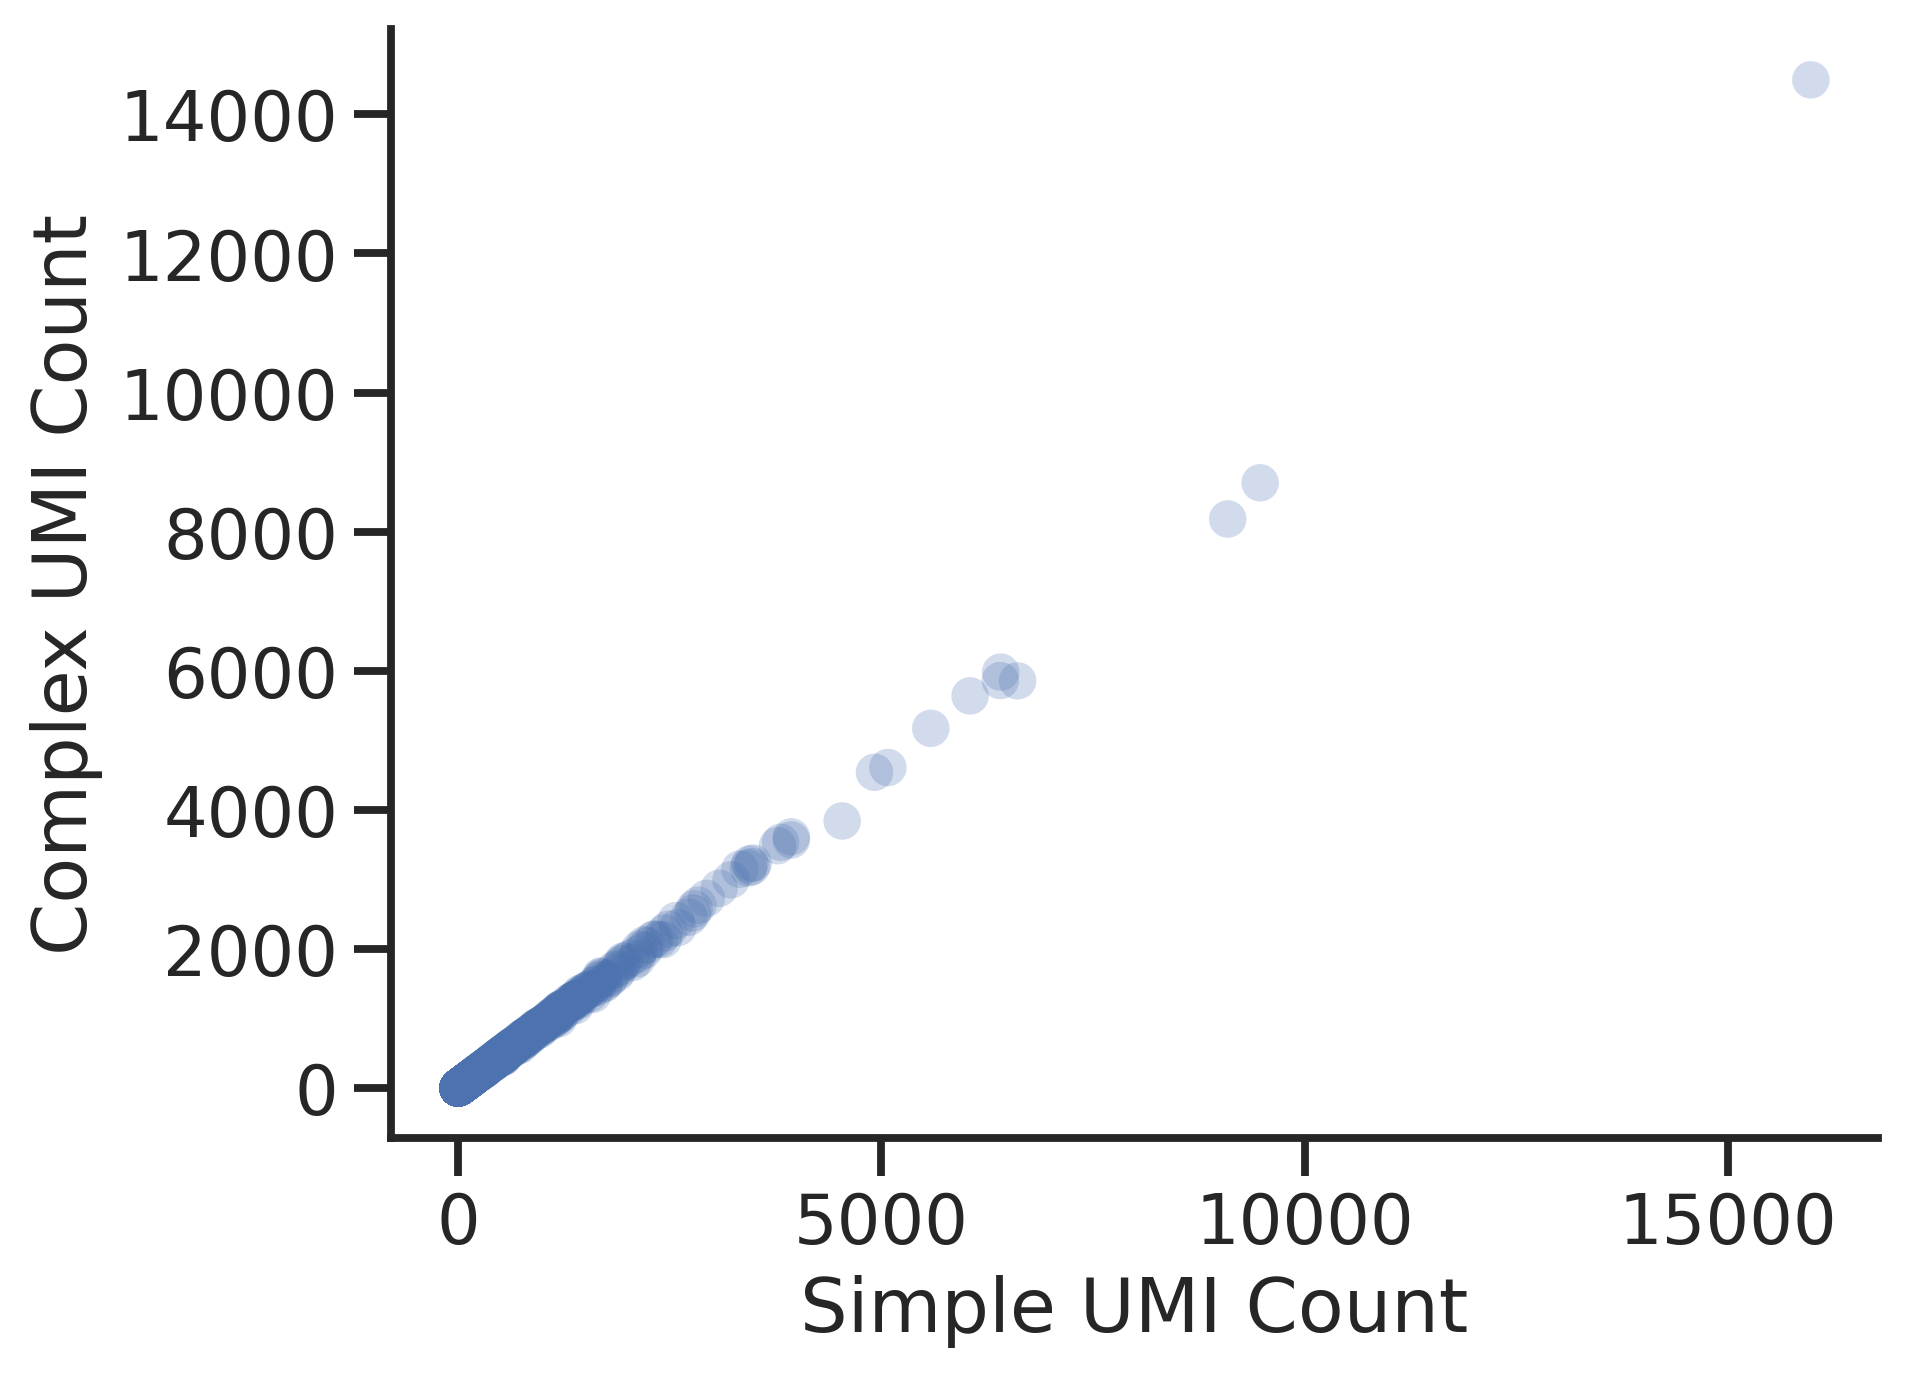

In [20]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.scatterplot(data = merged_RT_df.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_directional", 
                edgecolor = 'none',
               alpha = 0.25)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Complex UMI Count")

Text(0, 0.5, 'Difference from\nComplex UMI Count')

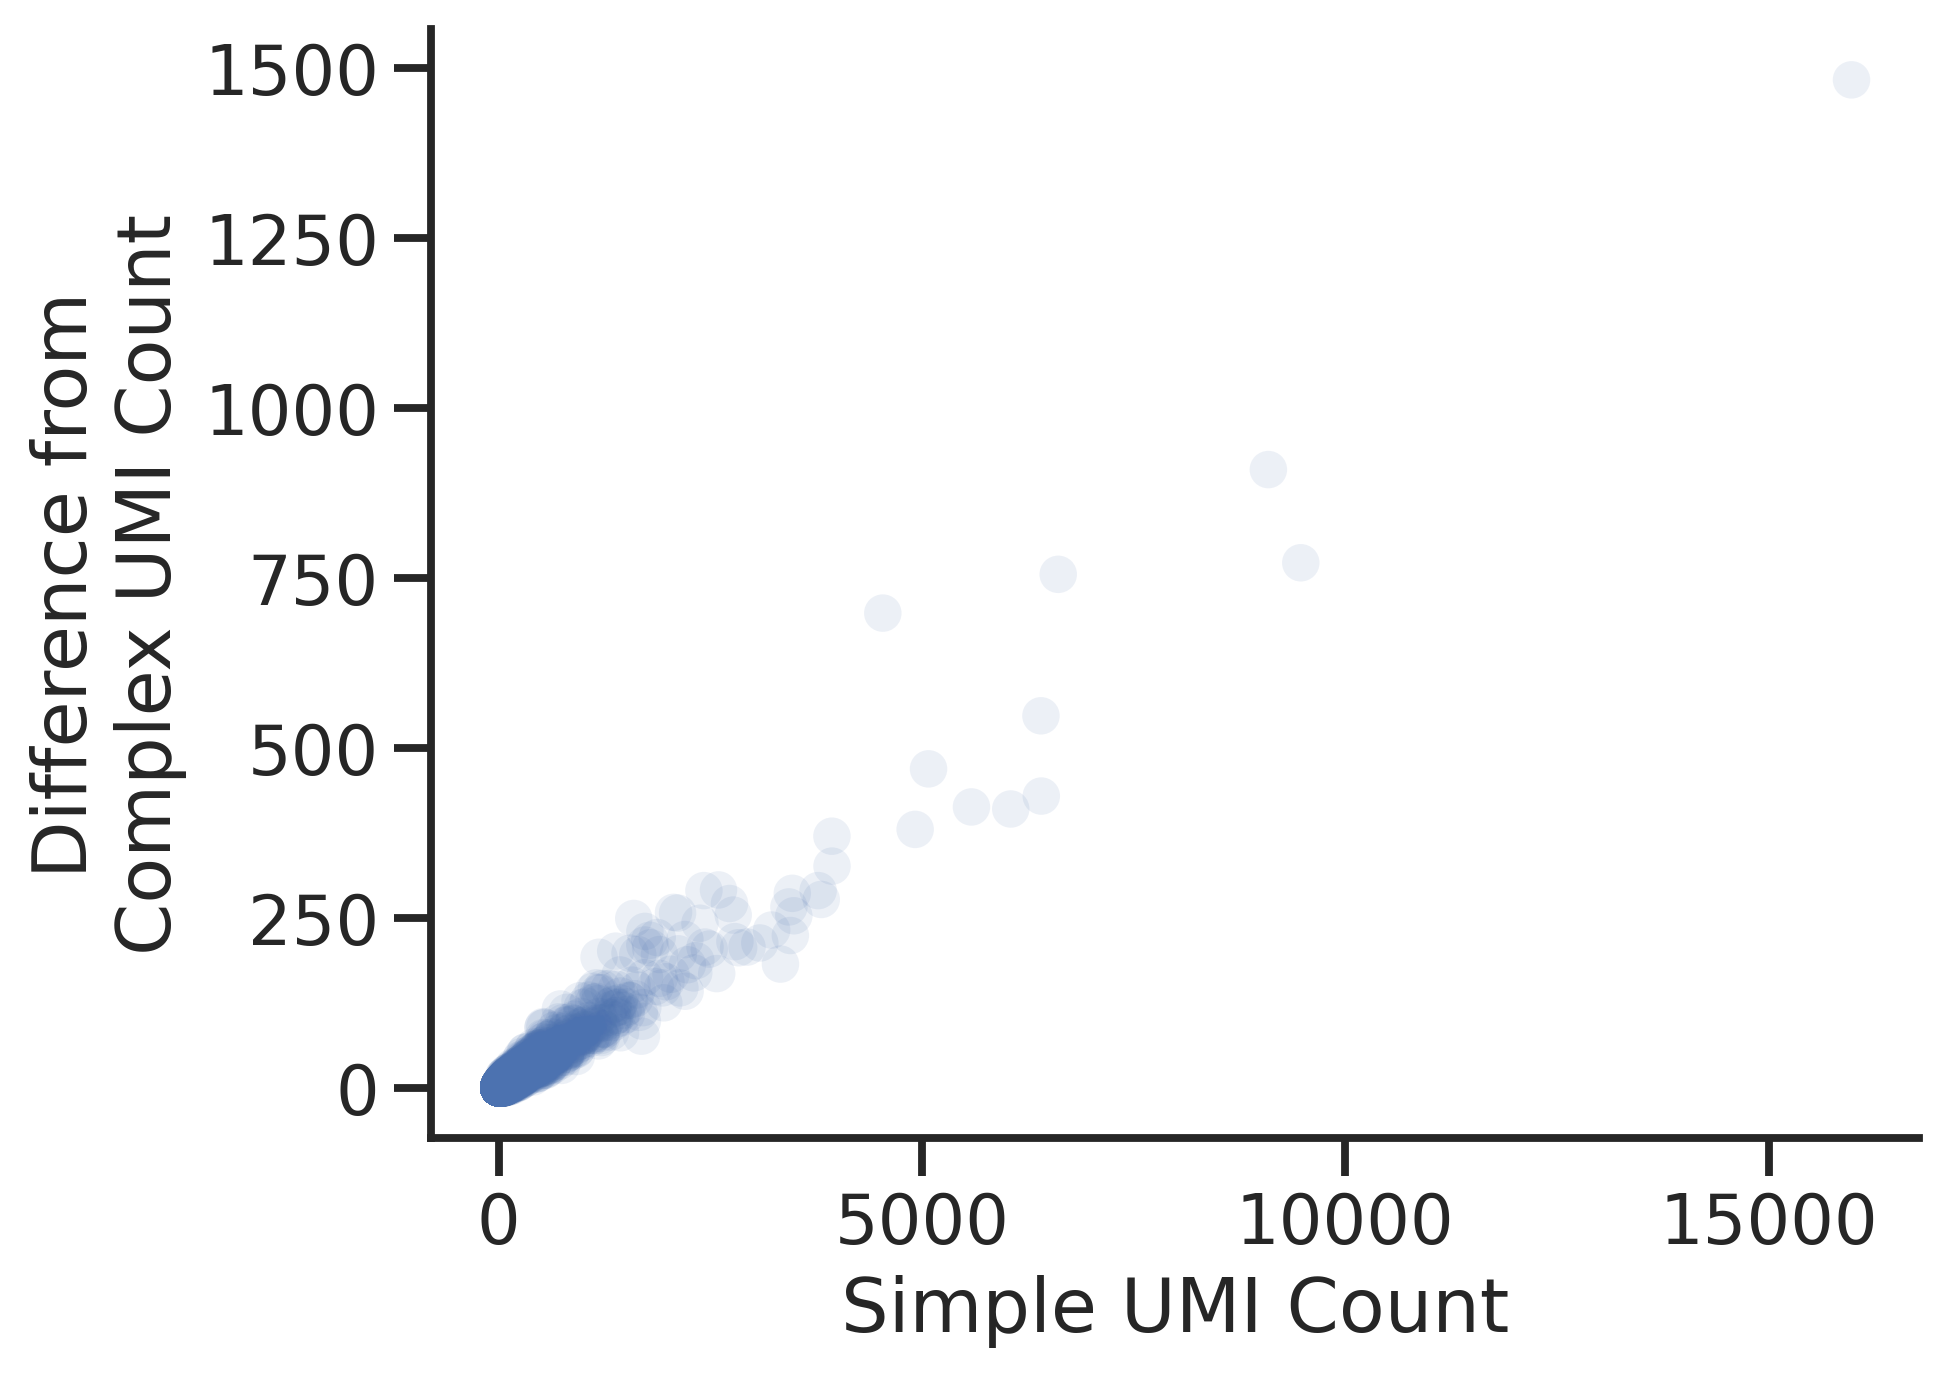

In [21]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)

sns.scatterplot(data = merged_RT_df.sample(100000, random_state = 44), 
                x = "count_simple", 
                y = "count_diff", 
                edgecolor = 'none',
               alpha = 0.1)
sns.despine()
plt.xlabel("Simple UMI Count")
plt.ylabel("Difference from\nComplex UMI Count")

In [22]:
merged_RT_df.to_csv("../../../output/ChopTFs_pipeline/RT_trebl_experiment_results.csv")

# Merging with step 1

In [23]:
step1_map_AD = pd.merge(step1_map, 
                        merged_AD_df[["AD_end", "AD_BC", "count_simple", "count_directional", "rep", "time"]])
step1_map_AD

,AD,AD_end,AD_BC,RPTR_BC,count_simple,count_directional,rep,time
0,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,13,13,4,50
1,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,5,5,3,30
2,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,10,10,3,50
3,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,10,10,4,15
4,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,11,10,2,60
...,...,...,...,...,...,...,...,...
1792768,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,9,9,2,15
1792769,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,2,2,2,30
1792770,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,1,1,2,0
1792771,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,11,11,4,30


In [24]:
step1_map_RT = pd.merge(step1_map, 
                        merged_RT_df[["RPTR_BC", "count_simple", "count_directional", "rep", "time"]])
step1_map_RT

,AD,AD_end,AD_BC,RPTR_BC,count_simple,count_directional,rep,time
0,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,1,1,4,30
1,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,2,2,2,20
2,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,5,4,2,2
3,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,1,1,2,30
4,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,1,1,3,60
...,...,...,...,...,...,...,...,...
1396448,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,1,1,2,30
1396449,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,1,1,4,20
1396450,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,2,2,2,40
1396451,TGGGGTTGTTATATTGCTGATCACTTTATTTGTTTGATGTTGGGTA...,GCCAGAATCTGATGAATTGCCAGAAGTTAATGGTACTGAA,CTCTCGCGTAA,TGTGTCACTATAGC,1,1,3,5


In [25]:
AD_RT_merged = pd.merge(step1_map_AD, step1_map_RT, how = 'outer', on = ["AD", "AD_end", "AD_BC", "RPTR_BC", "rep", "time"], suffixes = ("_AD", "_RT"))
AD_RT_merged

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0
...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0


In [26]:
# 1.8% of AD results are null when merged to step 1
100 * sum(AD_RT_merged["count_simple_AD"].isna()) / len(AD_RT_merged)

1.8893480370186126

In [27]:
# 23% of RT results are null when merged to step 1
100 * sum(AD_RT_merged["count_simple_RT"].isna()) / len(AD_RT_merged)

23.57821416004076

In [28]:
# For now, ignore the nulls
AD_RT_merged = AD_RT_merged.dropna()
AD_RT_merged

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0
...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0


In [29]:
AD_RT_merged["activity_simple"] = np.log10(AD_RT_merged["count_simple_RT"] / AD_RT_merged["count_simple_AD"])
AD_RT_merged

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508
...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266


In [30]:
AD_RT_merged["activity_directional"] = np.log10(AD_RT_merged["count_directional_RT"] / AD_RT_merged["count_directional_AD"])
AD_RT_merged

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104
...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060


In [31]:
# AD_RT_merged["log_activity_simple"] = np.log10(AD_RT_merged["count_simple_RT"] / AD_RT_merged["count_simple_AD"])
# AD_RT_merged

In [32]:
# AD_RT_merged["log_activity_directional"] = np.log10(AD_RT_merged["count_directional_RT"] / AD_RT_merged["count_directional_AD"])
# AD_RT_merged

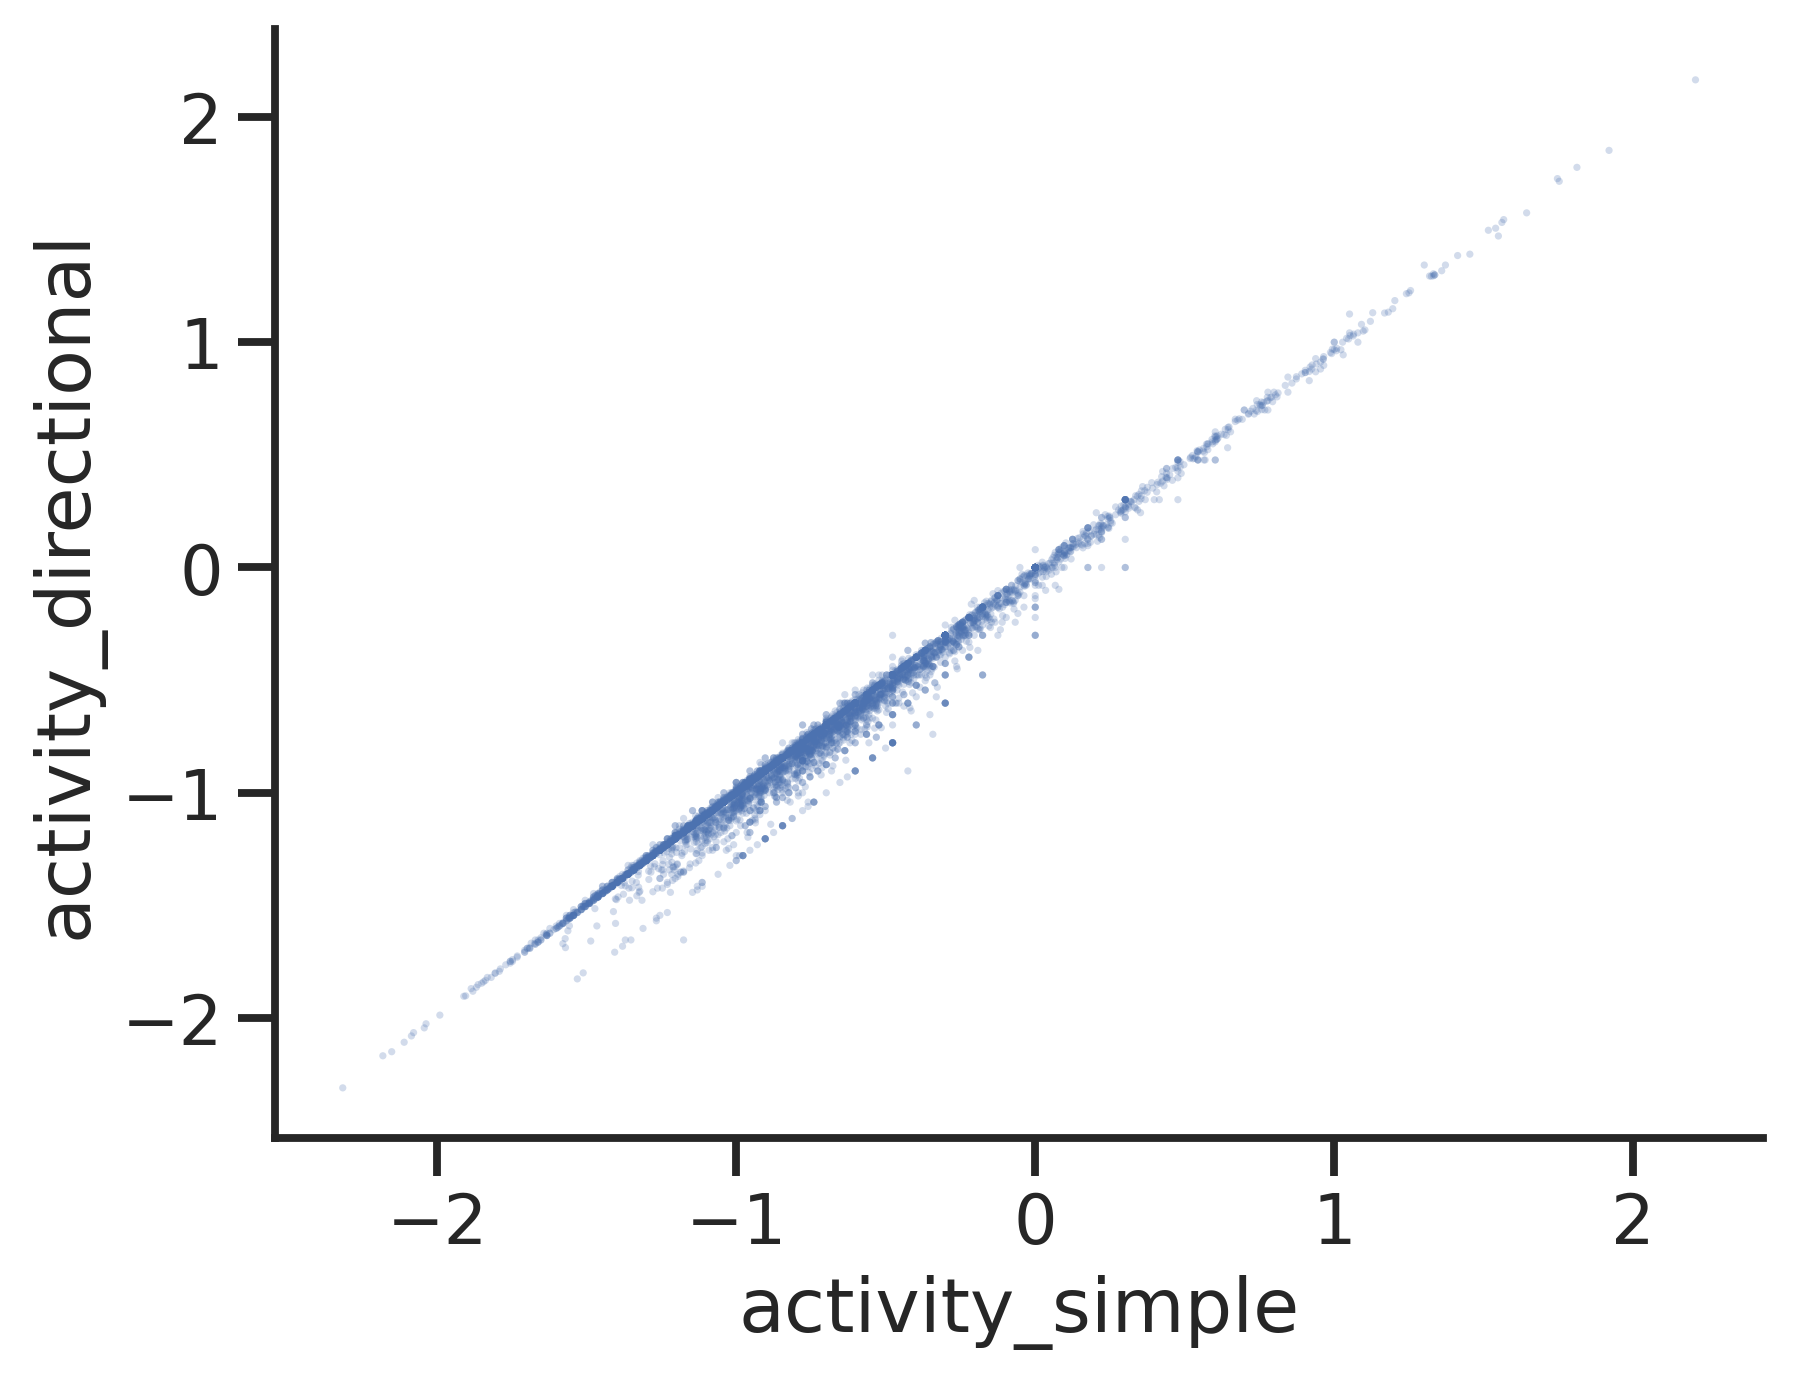

In [33]:
plt.figure(dpi = 300)
ax = sns.scatterplot(data = AD_RT_merged.sample(5000), x = 'activity_simple', y = "activity_directional", edgecolor = 'none', alpha = 0.25, s = 3)

sns.despine()

In [34]:
from Bio.Seq import Seq

AD_RT_merged["AD_protein"] = AD_RT_merged["AD"].apply(
    lambda x: str(Seq(x).translate())
)
AD_RT_merged

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [35]:
AD_RT_merged.to_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv")

# Merging per AD

In [36]:
AD_RT_merged = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", engine = 'python')
AD_RT_merged

,Unnamed: 0,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361924,1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361925,1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361926,1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361927,1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [37]:
AD_counts = pd.DataFrame( AD_RT_merged[["AD", "rep", "time"]].drop_duplicates().groupby(["rep", "time"]).size()).reset_index()
AD_counts

,rep,time,0
0,2,0,15258
1,2,2,15510
2,2,5,15110
3,2,10,15869
4,2,15,15927
5,2,20,16011
6,2,30,15980
7,2,40,16012
8,2,50,16090
9,2,60,15992


In [38]:
AD_activity_and_error = AD_RT_merged[["AD_protein", "activity_simple", "activity_directional", "rep", "time"]].groupby(["AD_protein", "rep", "time"]).agg([np.mean, np.std, "count"]).reset_index()
AD_activity_and_error.columns = ["AD_protein", "rep", "time", "activity_simple_mean", "activity_simple_std", "count",
                                 "activity_directional_mean", "activity_directional_std", "rep_count"]
AD_activity_and_error = AD_activity_and_error.drop(columns = ["count"])
AD_activity_and_error

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,0.602060,NaN,0.602060,NaN,1
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,0.000000,NaN,0.000000,NaN,1
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3
...,...,...,...,...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,-0.903090,NaN,-0.954243,NaN,1
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,-1.036984,NaN,-1.141674,NaN,1
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,-1.036984,NaN,-1.083682,NaN,1
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,-1.063387,NaN,-1.063387,NaN,1


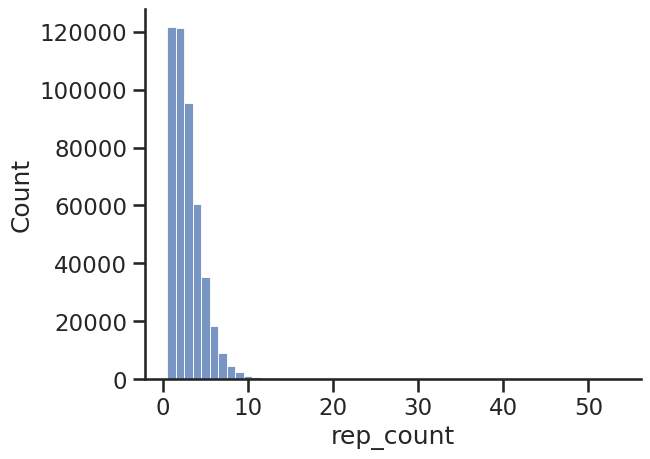

In [39]:
sns.histplot(AD_activity_and_error["rep_count"], binwidth = 1, discrete = True)
sns.despine()

In [40]:
AD_activity_and_error[AD_activity_and_error.isnull().any(axis=1)]

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,0.602060,NaN,0.602060,NaN,1
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,0.000000,NaN,0.000000,NaN,1
12,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,3,0,-0.713210,NaN,-0.713210,NaN,1
13,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,3,2,-0.869232,NaN,-0.857332,NaN,1
31,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,4,60,-0.636822,NaN,-0.636822,NaN,1
...,...,...,...,...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,-0.903090,NaN,-0.954243,NaN,1
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,-1.036984,NaN,-1.141674,NaN,1
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,-1.036984,NaN,-1.083682,NaN,1
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,-1.063387,NaN,-1.063387,NaN,1


In [41]:
AD_activity_and_error_multiple_reps = AD_activity_and_error.dropna()
AD_activity_and_error_multiple_reps

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,-0.684608,0.132290,-0.840621,0.337376,2
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,-0.544068,0.187561,-0.581385,0.134787,2
...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.051218,0.341356,0.012307,0.337090,4
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,-0.935786,0.471961,-0.935786,0.471961,2
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,-0.411954,0.582591,-0.430849,0.609312,2
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,-0.471889,0.844041,-0.505362,0.891380,2


In [42]:
len(AD_activity_and_error["AD_protein"].unique())

16830

In [43]:
len(AD_activity_and_error_multiple_reps["AD_protein"].unique())

13916

In [44]:
AD_mulitp_rep_counts = pd.DataFrame(AD_activity_and_error_multiple_reps[["AD_protein", "rep", "time"]].drop_duplicates().groupby(["rep", "time"]).size()).reset_index()
AD_mulitp_rep_counts

,rep,time,0
0,2,0,10671
1,2,2,11226
2,2,5,10465
3,2,10,11905
4,2,15,11984
5,2,20,12221
6,2,30,12136
7,2,40,12221
8,2,50,12382
9,2,60,12192


Text(0.5, 0.98, 'ChopTFs Trebl Experiment')

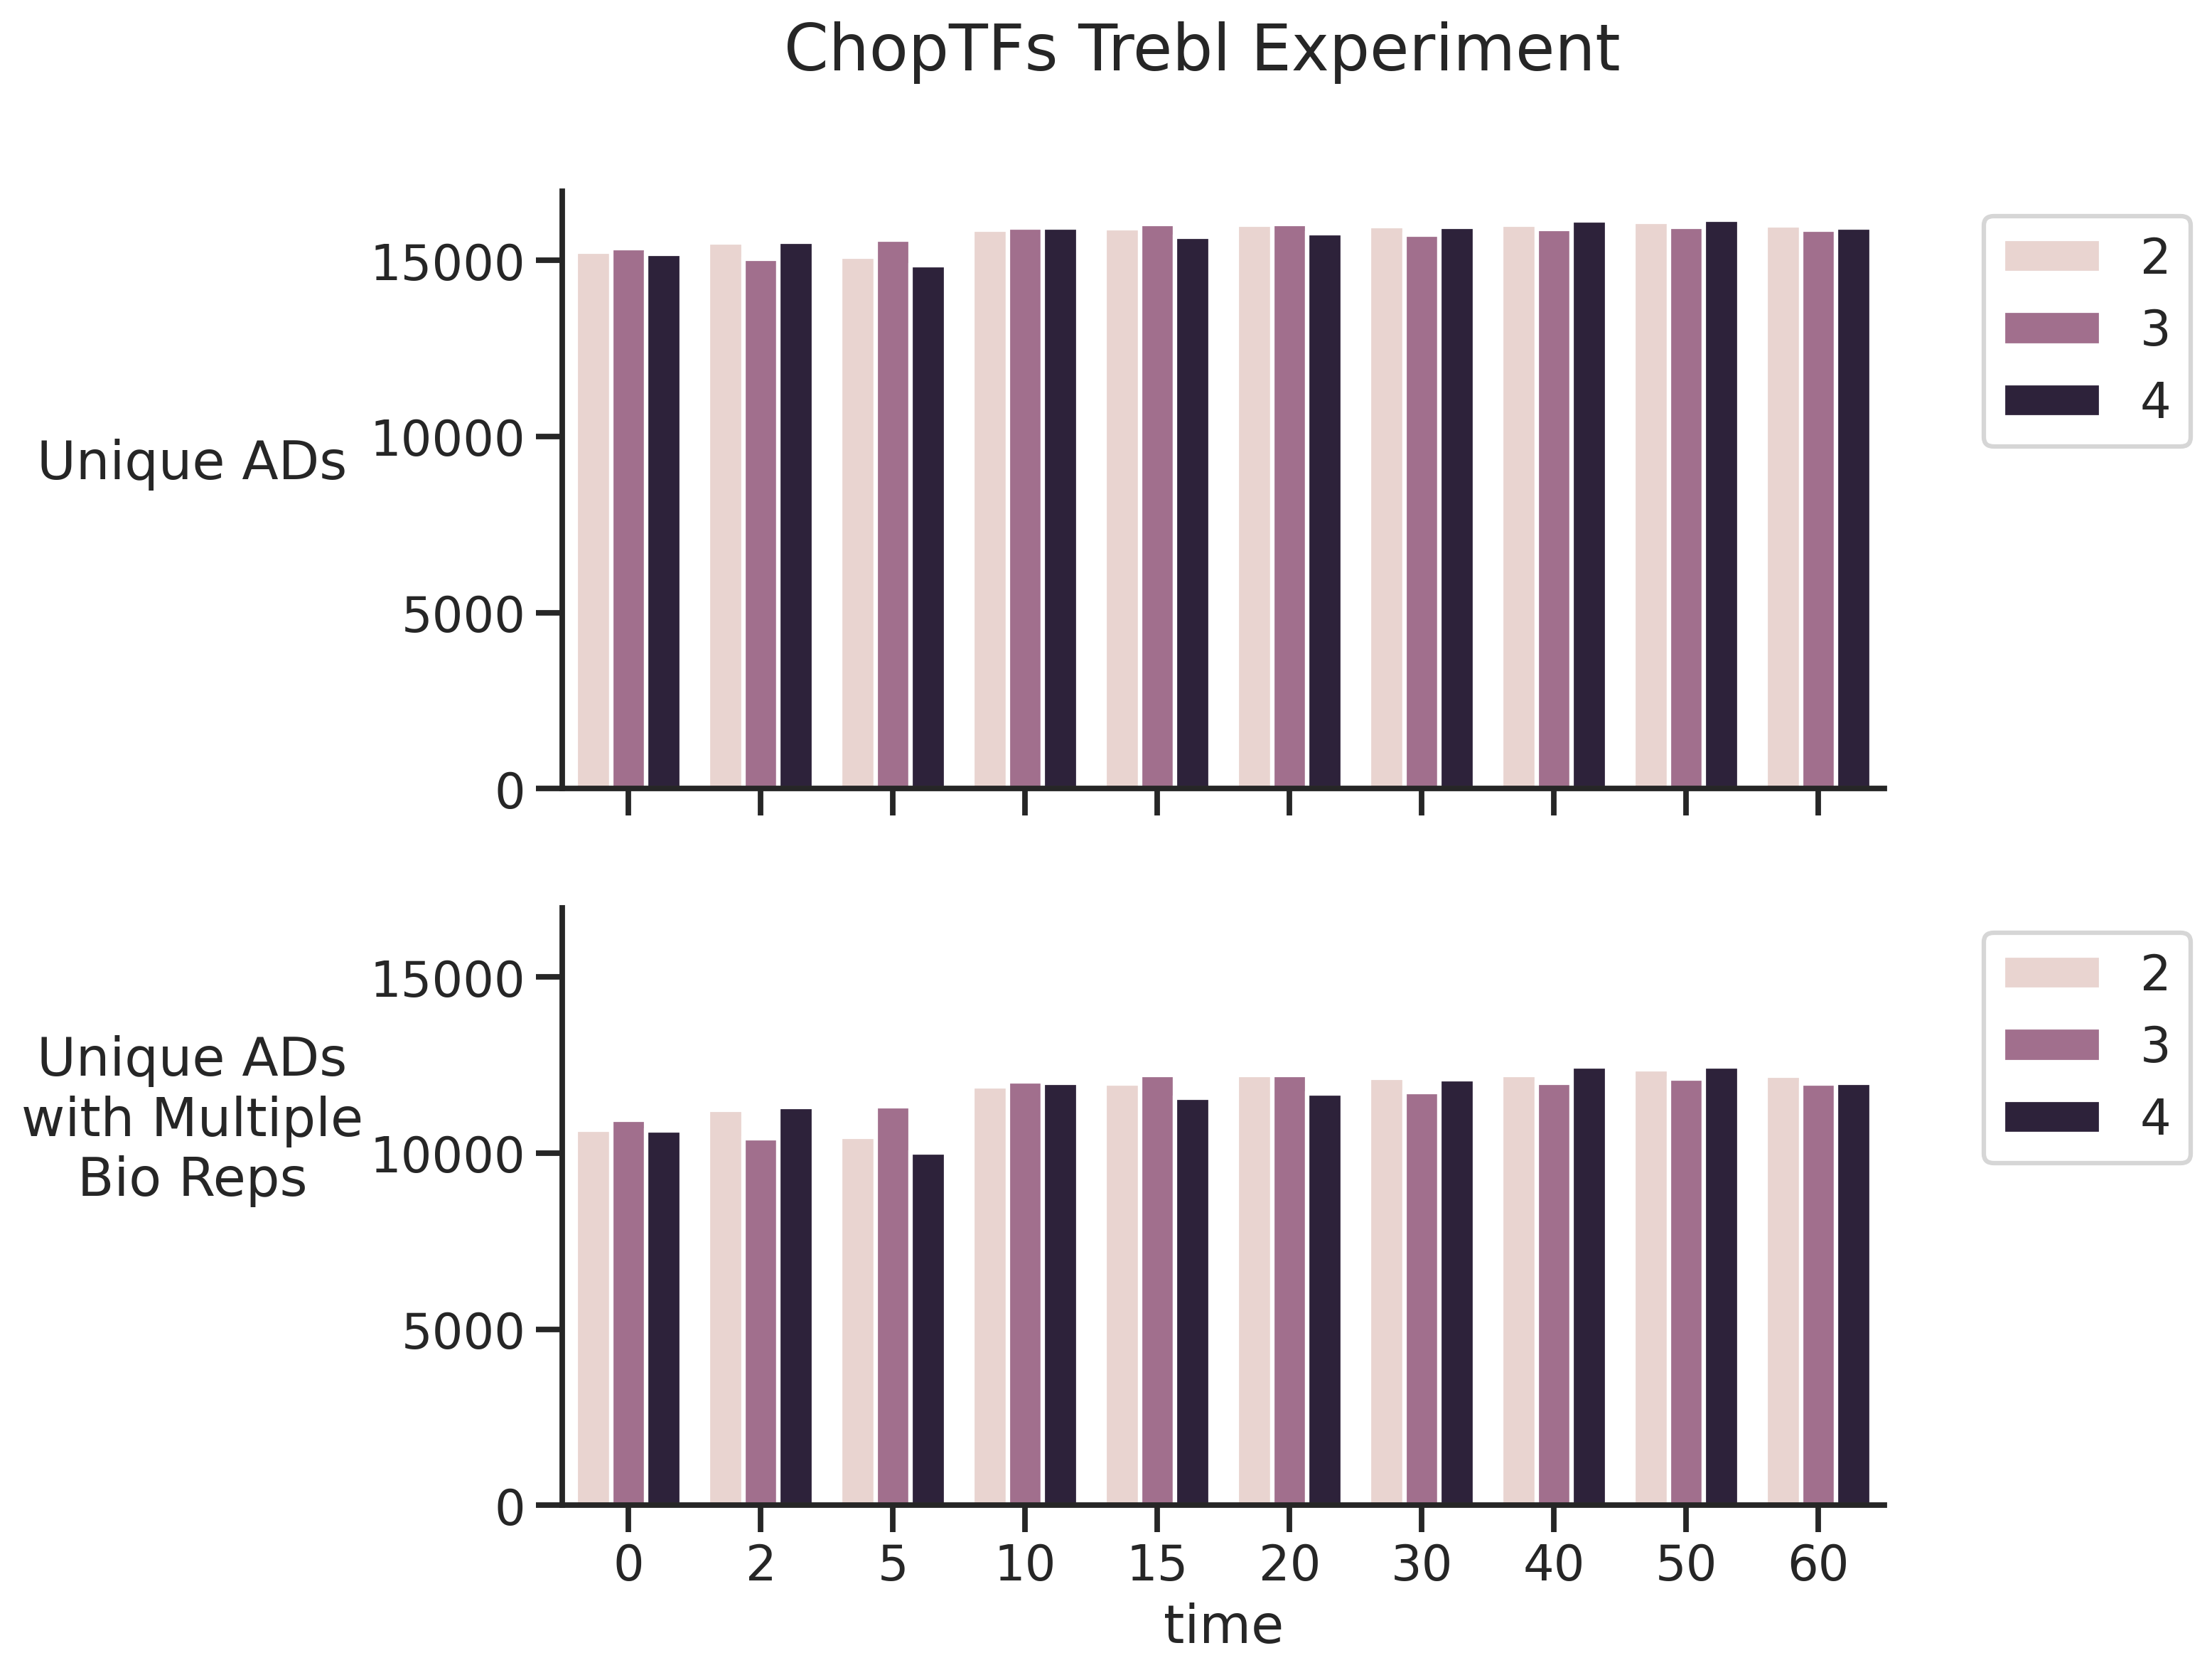

In [45]:
fig,axs = plt.subplots(2,1, dpi = 300, sharex = True, sharey = True, figsize = (8,8))

sns.barplot(data = AD_counts, x = "time", y = 0, hue = "rep", ax = axs[0])
axs[0].set_ylabel("Unique ADs")
axs[0].legend(loc = 'upper right', bbox_to_anchor = (1.25,1))
axs[0].set_ylabel("Unique ADs", rotation = 0, labelpad = 60)

sns.barplot(data = AD_mulitp_rep_counts, x = "time", y = 0, hue = "rep", ax = axs[1])
sns.despine()
axs[1].legend(loc = 'upper right', bbox_to_anchor = (1.25,1))
axs[1].set_ylabel("Unique ADs\nwith Multiple\nBio Reps", labelpad = 60, rotation = 0)
fig.suptitle("ChopTFs Trebl Experiment")

In [46]:
AD_activity_and_error_multiple_reps["activity_simple_cv"] = AD_activity_and_error_multiple_reps["activity_simple_std"] / AD_activity_and_error_multiple_reps["activity_simple_mean"]
AD_activity_and_error_multiple_reps["activity_directional_cv"] = AD_activity_and_error_multiple_reps["activity_directional_std"] / AD_activity_and_error_multiple_reps["activity_directional_mean"]
AD_activity_and_error_multiple_reps

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2,-0.085783,-0.085783
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3,-0.354050,-0.330522
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3,-0.505070,-0.592845
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,-0.684608,0.132290,-0.840621,0.337376,2,-0.193235,-0.401341
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,-0.544068,0.187561,-0.581385,0.134787,2,-0.344738,-0.231838
...,...,...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.051218,0.341356,0.012307,0.337090,4,6.664764,27.389808
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,-0.935786,0.471961,-0.935786,0.471961,2,-0.504346,-0.504346
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,-0.411954,0.582591,-0.430849,0.609312,2,-1.414214,-1.414214
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,-0.471889,0.844041,-0.505362,0.891380,2,-1.788645,-1.763844


In [47]:
# from Bio.Seq import Seq

# AD_activity_and_error_multiple_reps["AD_protein"] = AD_activity_and_error_multiple_reps["AD"].apply(
#     lambda x: str(Seq(x).translate())
# )
# AD_activity_and_error_multiple_reps

In [48]:
AD_activity_and_error_multiple_reps.to_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_AD.csv")

In [49]:
pd.DataFrame(AD_activity_and_error_multiple_reps[AD_activity_and_error_multiple_reps["activity_simple_cv"] < 0.25][["rep", "time"]].value_counts())

count
rep time       
3   15    11651
4   10    11634
3   10    11625
2   10    11562
    20    11482
3   20    11474
2   15    11418
4   40    11339
    50    11323
    2     11284
3   5     11232
2   2     11209
4   30    11204
2   30    11184
    40    11168
    50    11141
4   15    11119
    20    11076
3   50    11054
2   60    11023
3   40    11003
4   60    10990
3   0     10942
    60    10851
    30    10848
2   0     10662
4   0     10637
3   2     10410
2   5     10394
4   5      9964

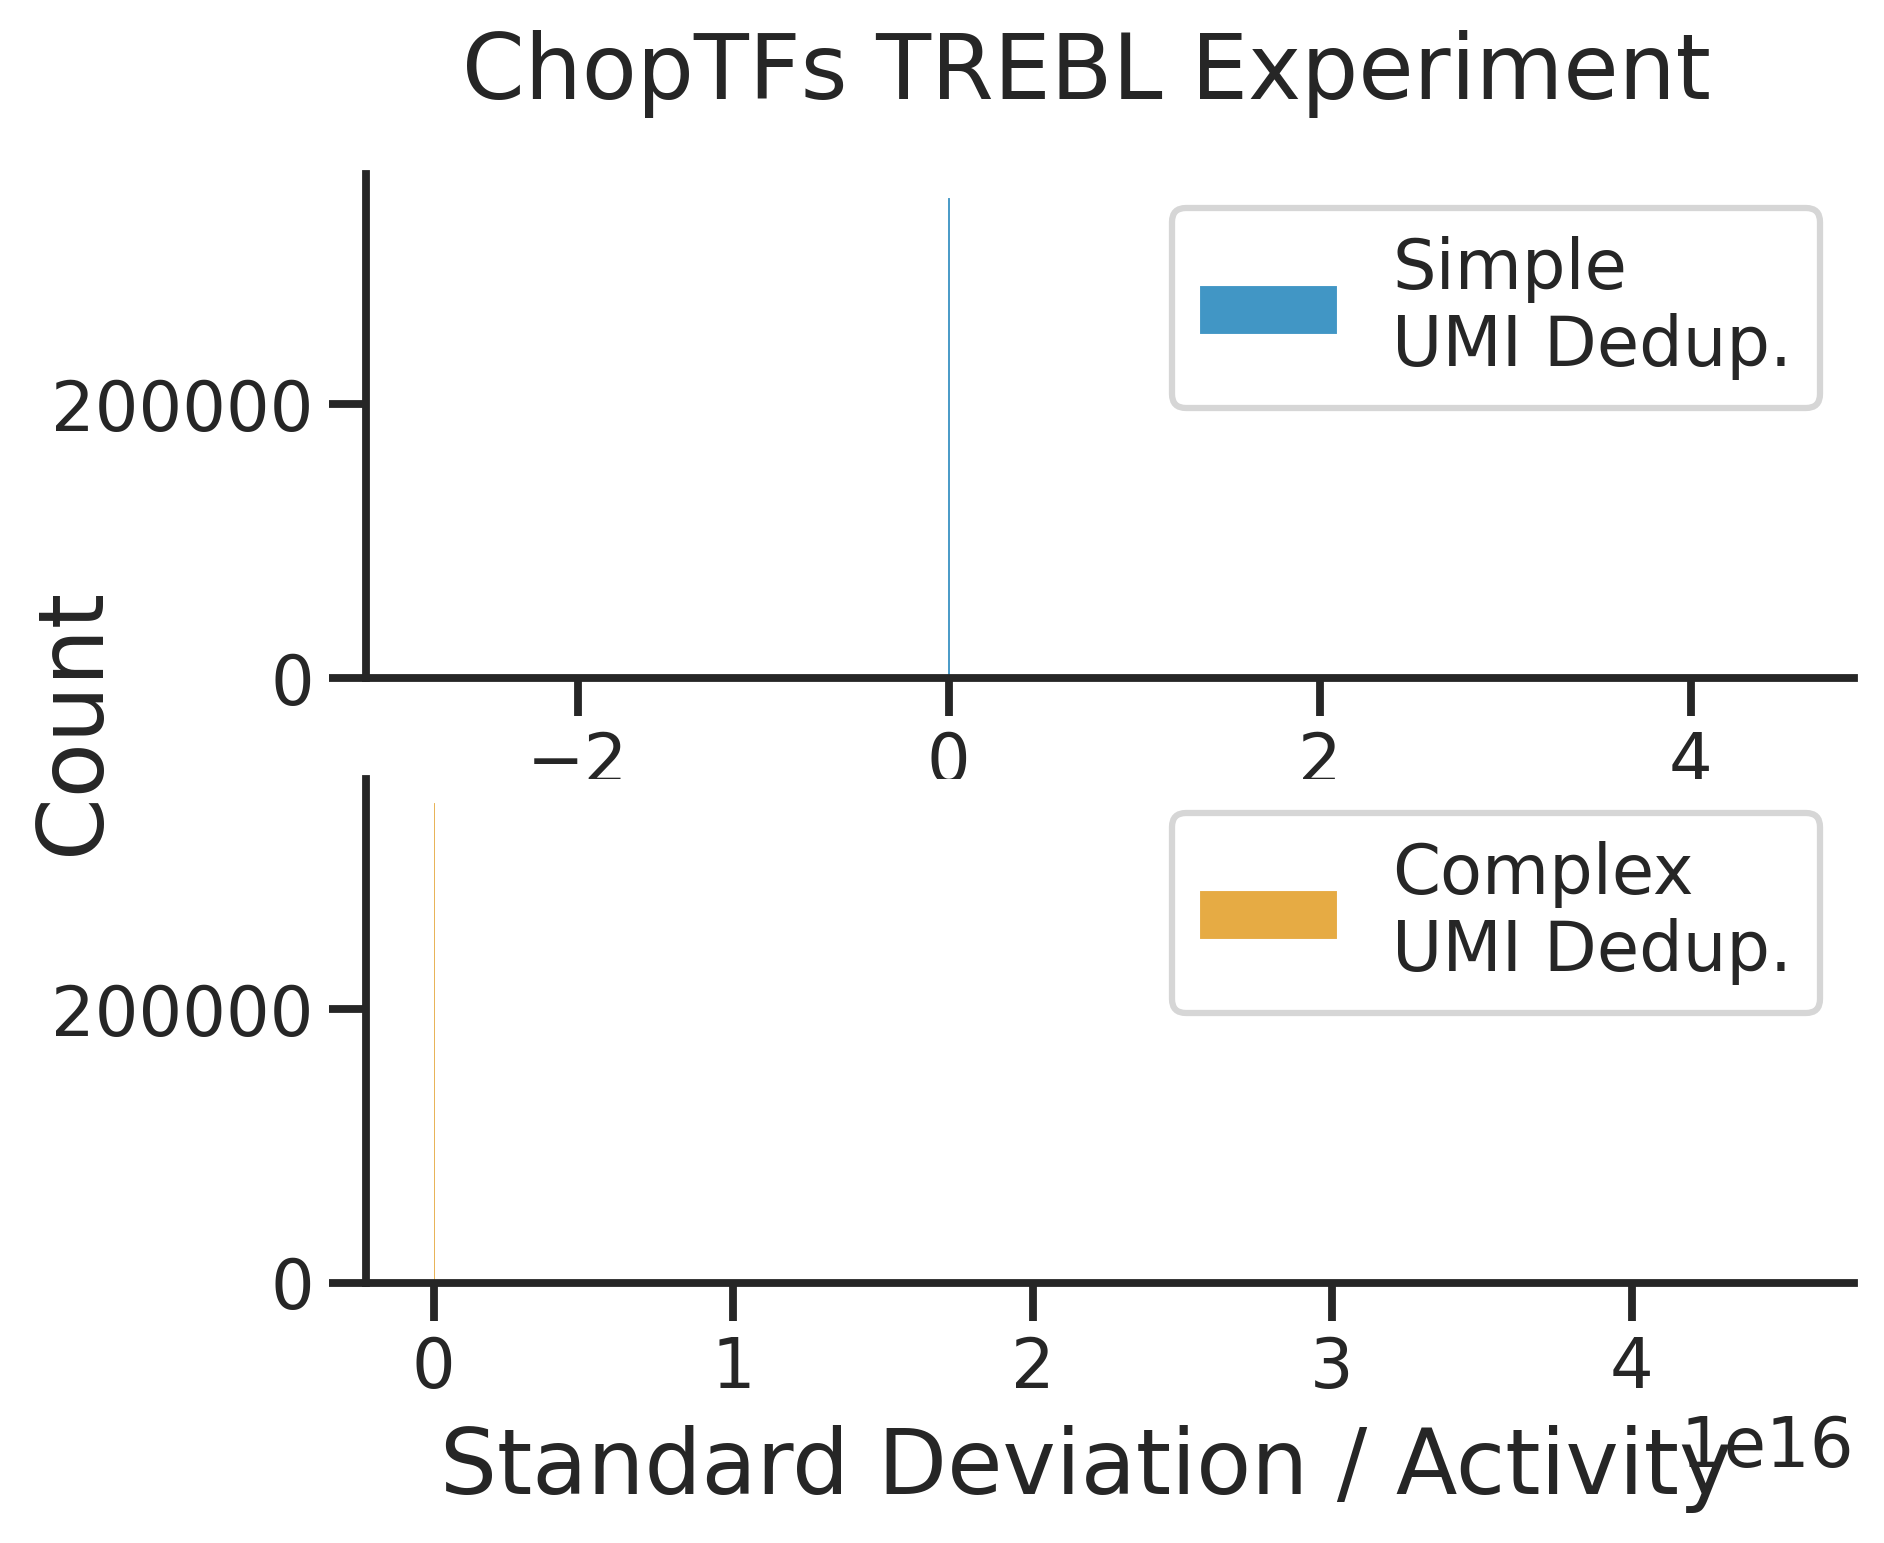

In [50]:
fig, axs = plt.subplots(2,1, dpi = 300, sharex = False)
sns.histplot(data = AD_activity_and_error_multiple_reps, x = "activity_simple_cv", ax = axs[0], label = "Simple\nUMI Dedup.", color = sns.color_palette('colorblind')[0])
sns.histplot(data = AD_activity_and_error_multiple_reps, x = "activity_directional_cv", ax = axs[1], label = "Complex\nUMI Dedup.", color = sns.color_palette('colorblind')[1])

for ax in axs:
    ax.legend()
    ax.set_ylabel("")
    ax.set_xlabel("")
    
fig.supxlabel("Standard Deviation / Activity", y = -0.05)
fig.supylabel("Count", x = -0.05)
fig.suptitle("ChopTFs TREBL Experiment")
sns.despine()

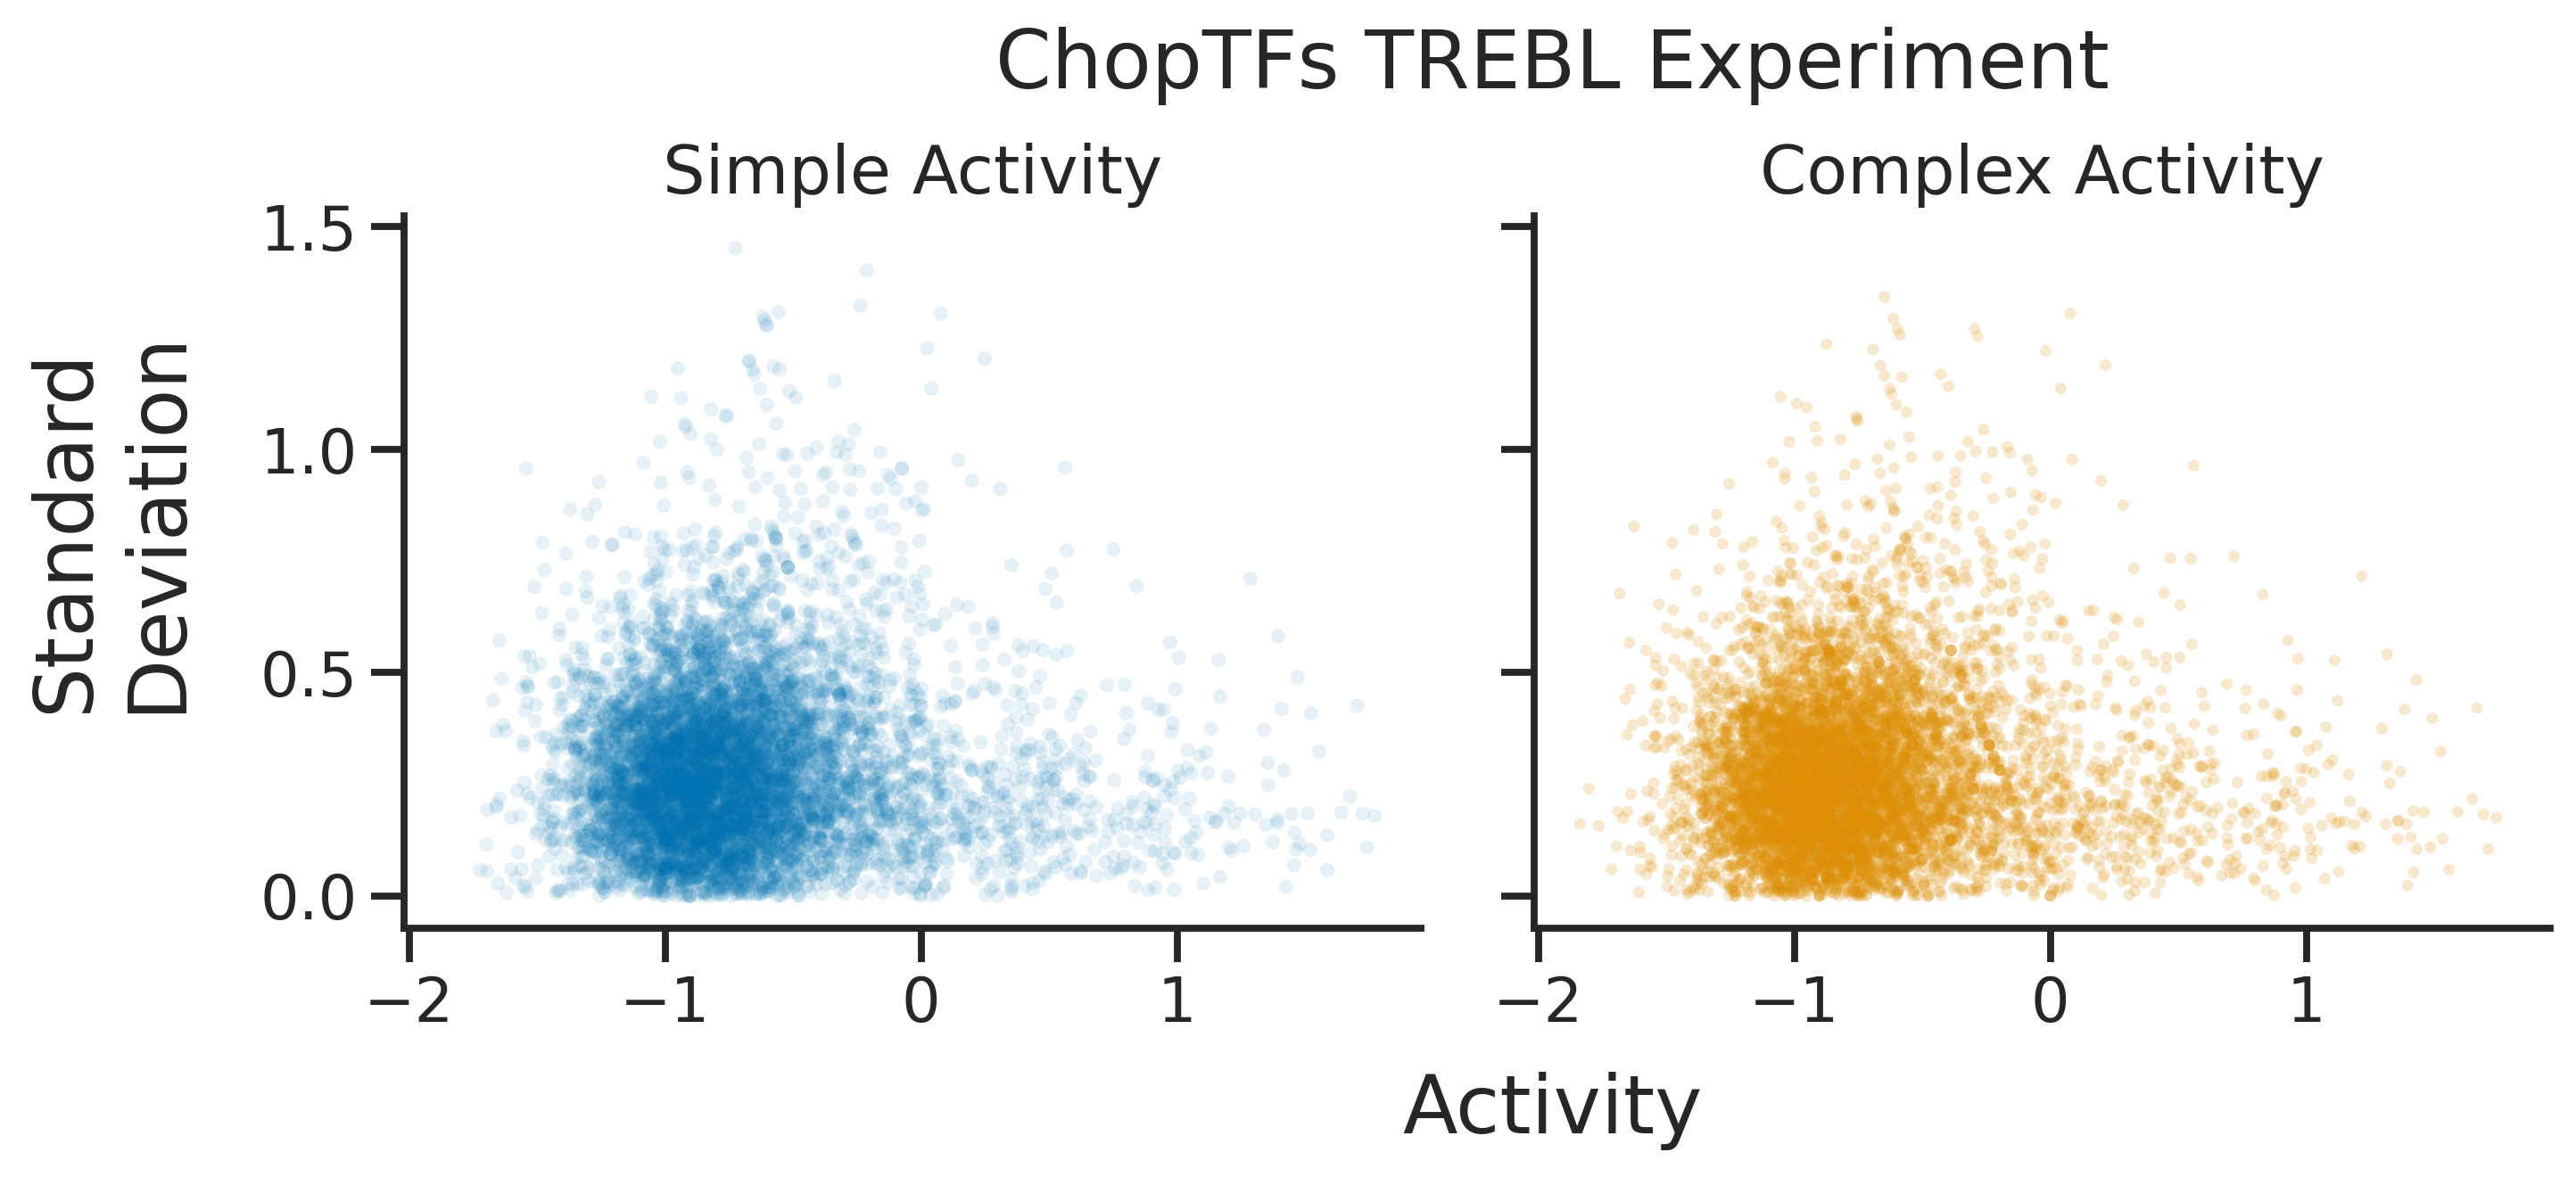

In [51]:
# Sample 100k rows for plotting
sample_data = AD_activity_and_error.sample(10000)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, sharey = True, sharex = True, figsize = (10,5), dpi = 300)  # 1 row, 2 columns

# --------- Simple mean vs std ---------
ax = axes[0]
sns.scatterplot(
    data=sample_data,
    x="activity_simple_mean",
    y="activity_simple_std",
    edgecolor='none',
    alpha=0.1,
    s=15,
    ax=ax, color = sns.color_palette('colorblind')[0]
)

# # axis limits
# xmin, xmax = ax.get_xlim()
# ymin, ymax = ax.get_ylim()
# lo = min(xmin, ymin)
# hi = max(xmax, ymax)

# ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color='red')
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_title("Simple Activity")

# --------- Directional mean vs std ---------
ax = axes[1]
sns.scatterplot(
    data=sample_data,
    x="activity_directional_mean",
    y="activity_directional_std",
    edgecolor='none',
    alpha=0.2,
    s=10,
    ax=ax, color = sns.color_palette('colorblind')[1]
)

# axis limits
# xmin, xmax = ax.get_xlim()
# ymin, ymax = ax.get_ylim()
# lo = min(xmin, ymin)
# hi = max(xmax, ymax)

# ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color='red')


# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_title("Complex Activity")

for ax in axes:
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.supxlabel("Activity", y = 0.08, x = 0.6)
fig.supylabel("Standard\nDeviation", x = 0.03, y = 0.55)
fig.suptitle("ChopTFs TREBL Experiment", y = 0.92, x = 0.6)

# Remove top/right spines
sns.despine(fig=fig)

plt.tight_layout()
plt.show()

In [61]:
AD_activity_and_error_multiple_reps

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2,-0.085783,-0.085783
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3,-0.354050,-0.330522
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3,-0.505070,-0.592845
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,-0.684608,0.132290,-0.840621,0.337376,2,-0.193235,-0.401341
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,-0.544068,0.187561,-0.581385,0.134787,2,-0.344738,-0.231838
...,...,...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.051218,0.341356,0.012307,0.337090,4,6.664764,27.389808
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,-0.935786,0.471961,-0.935786,0.471961,2,-0.504346,-0.504346
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,-0.411954,0.582591,-0.430849,0.609312,2,-1.414214,-1.414214
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,-0.471889,0.844041,-0.505362,0.891380,2,-1.788645,-1.763844


350762
350762


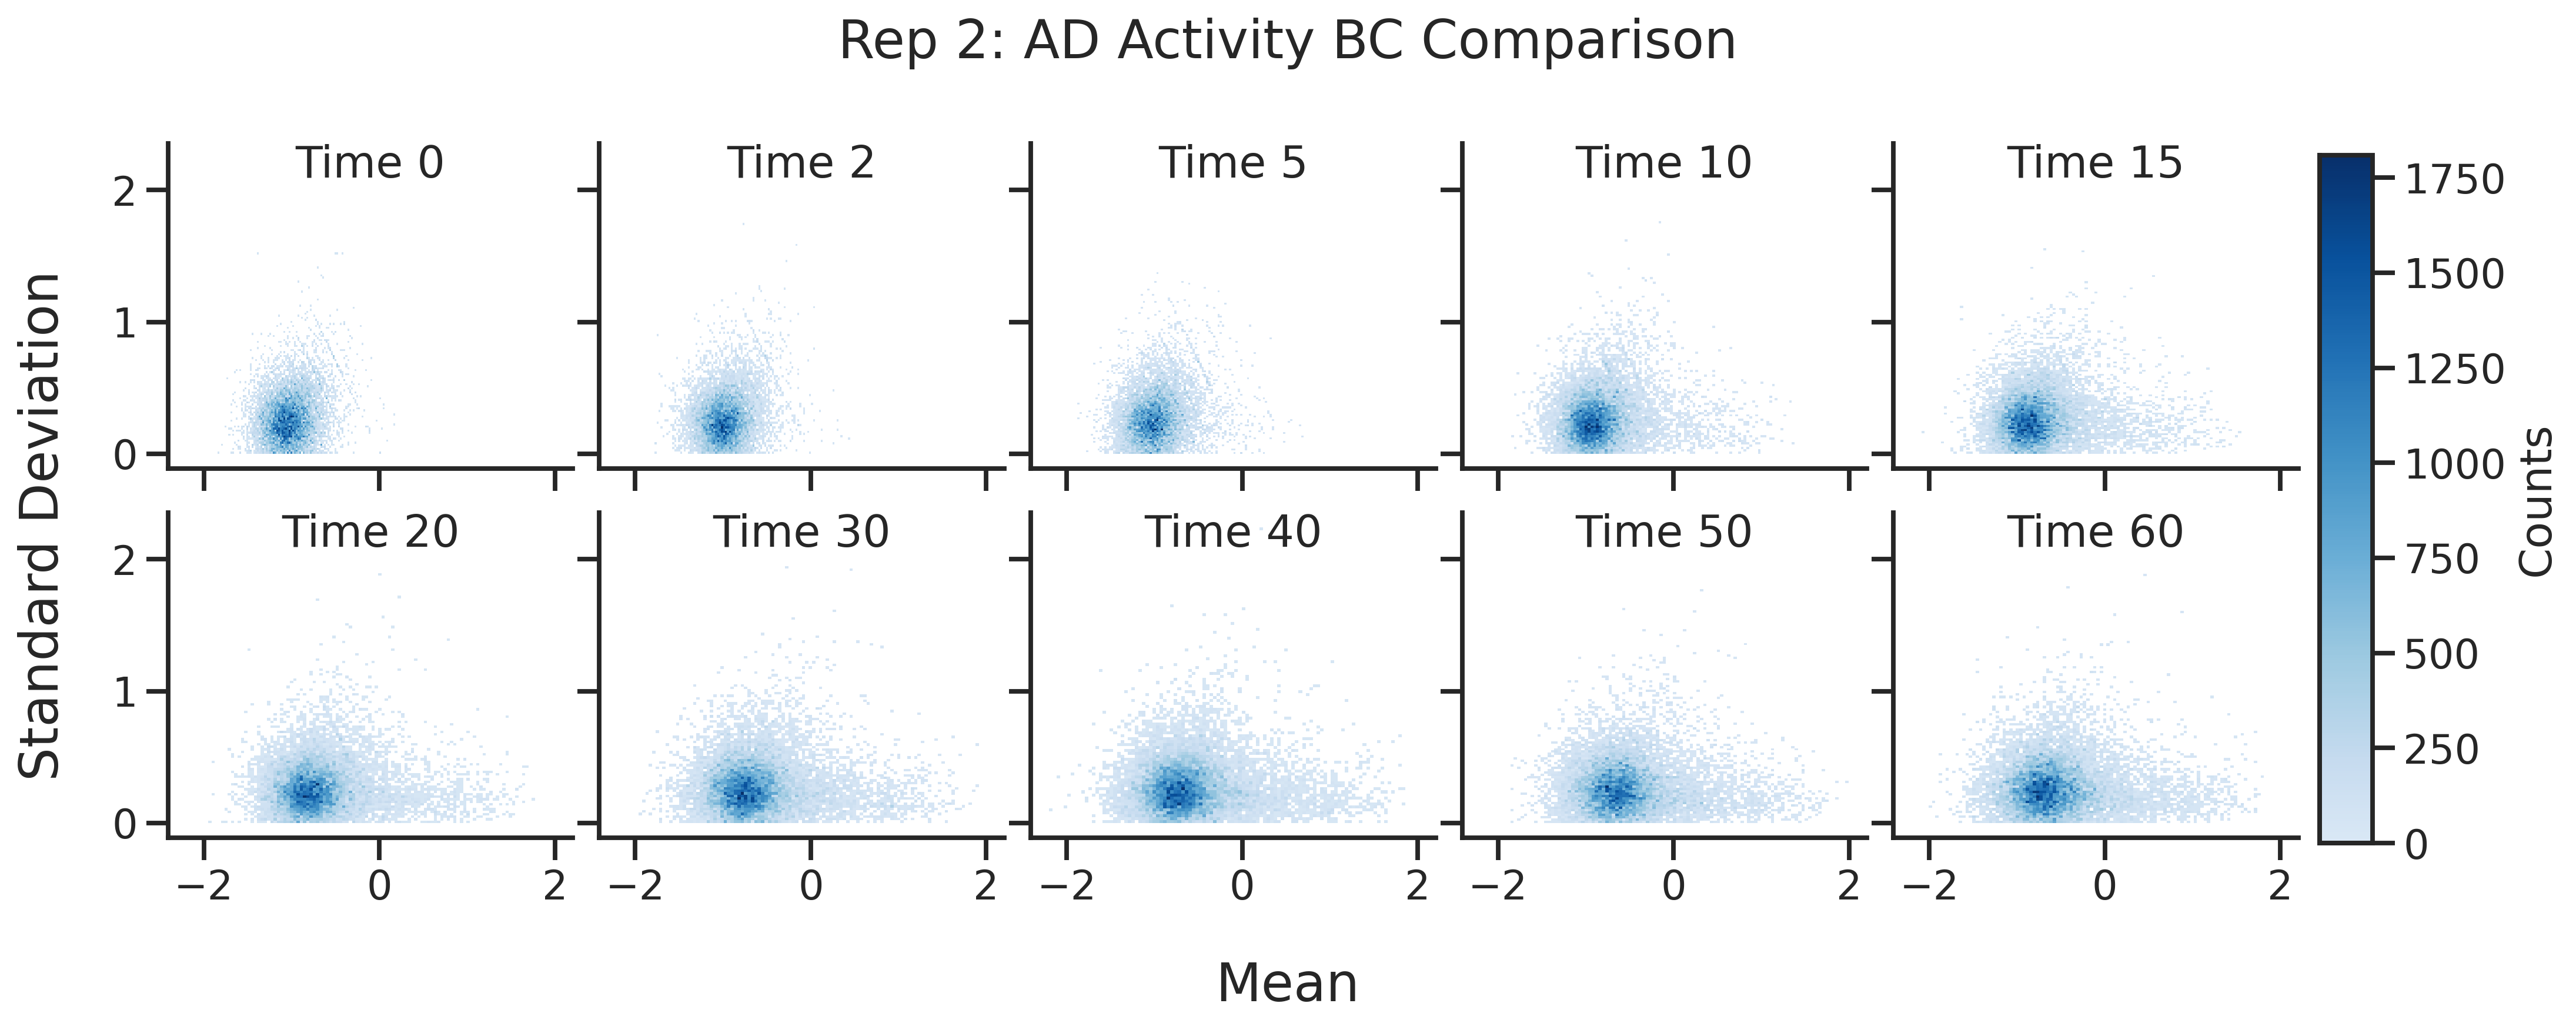

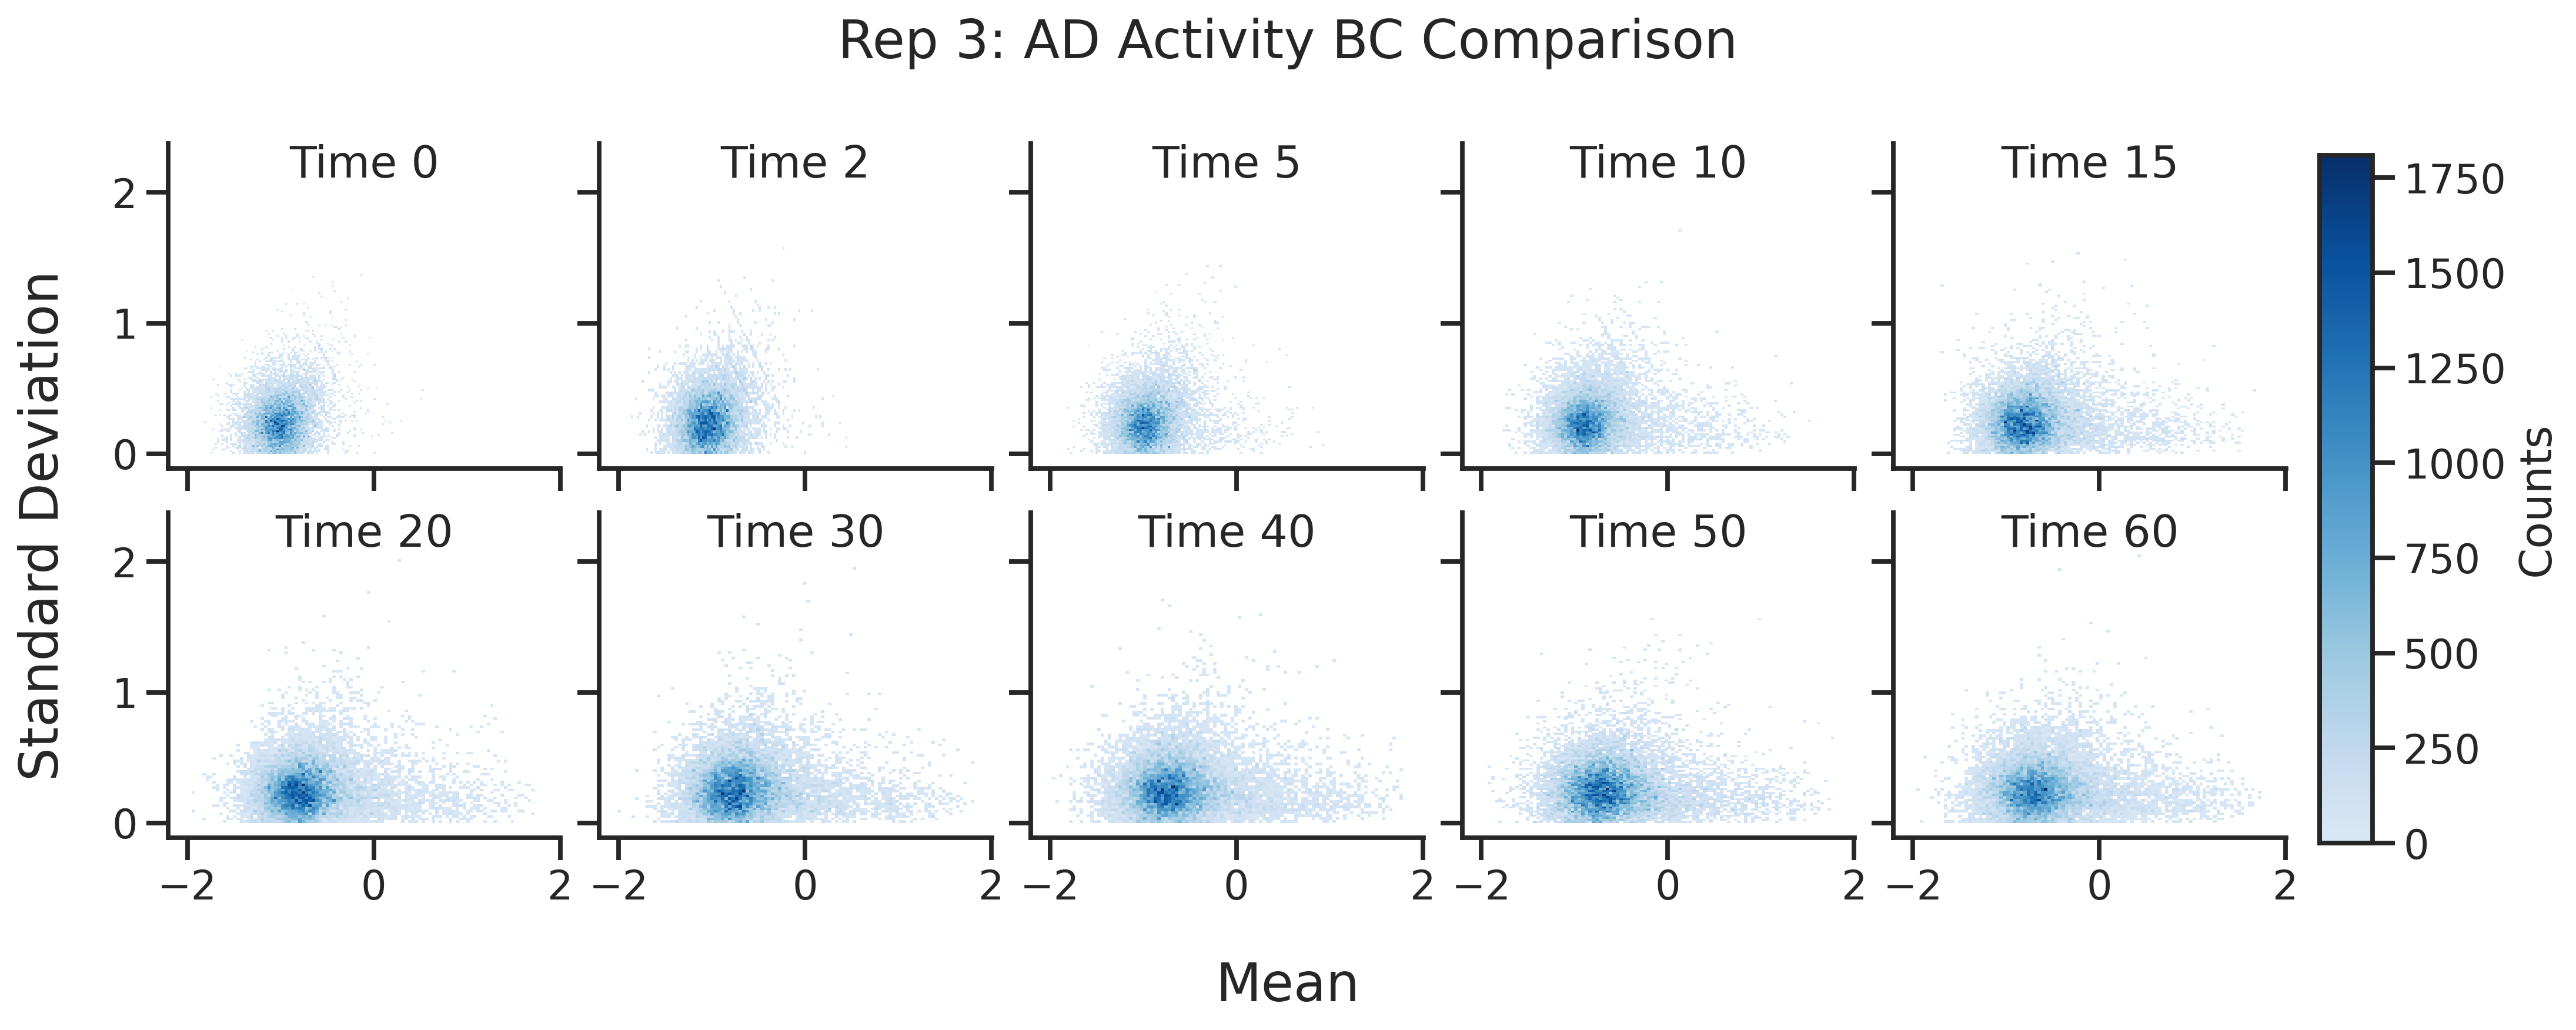

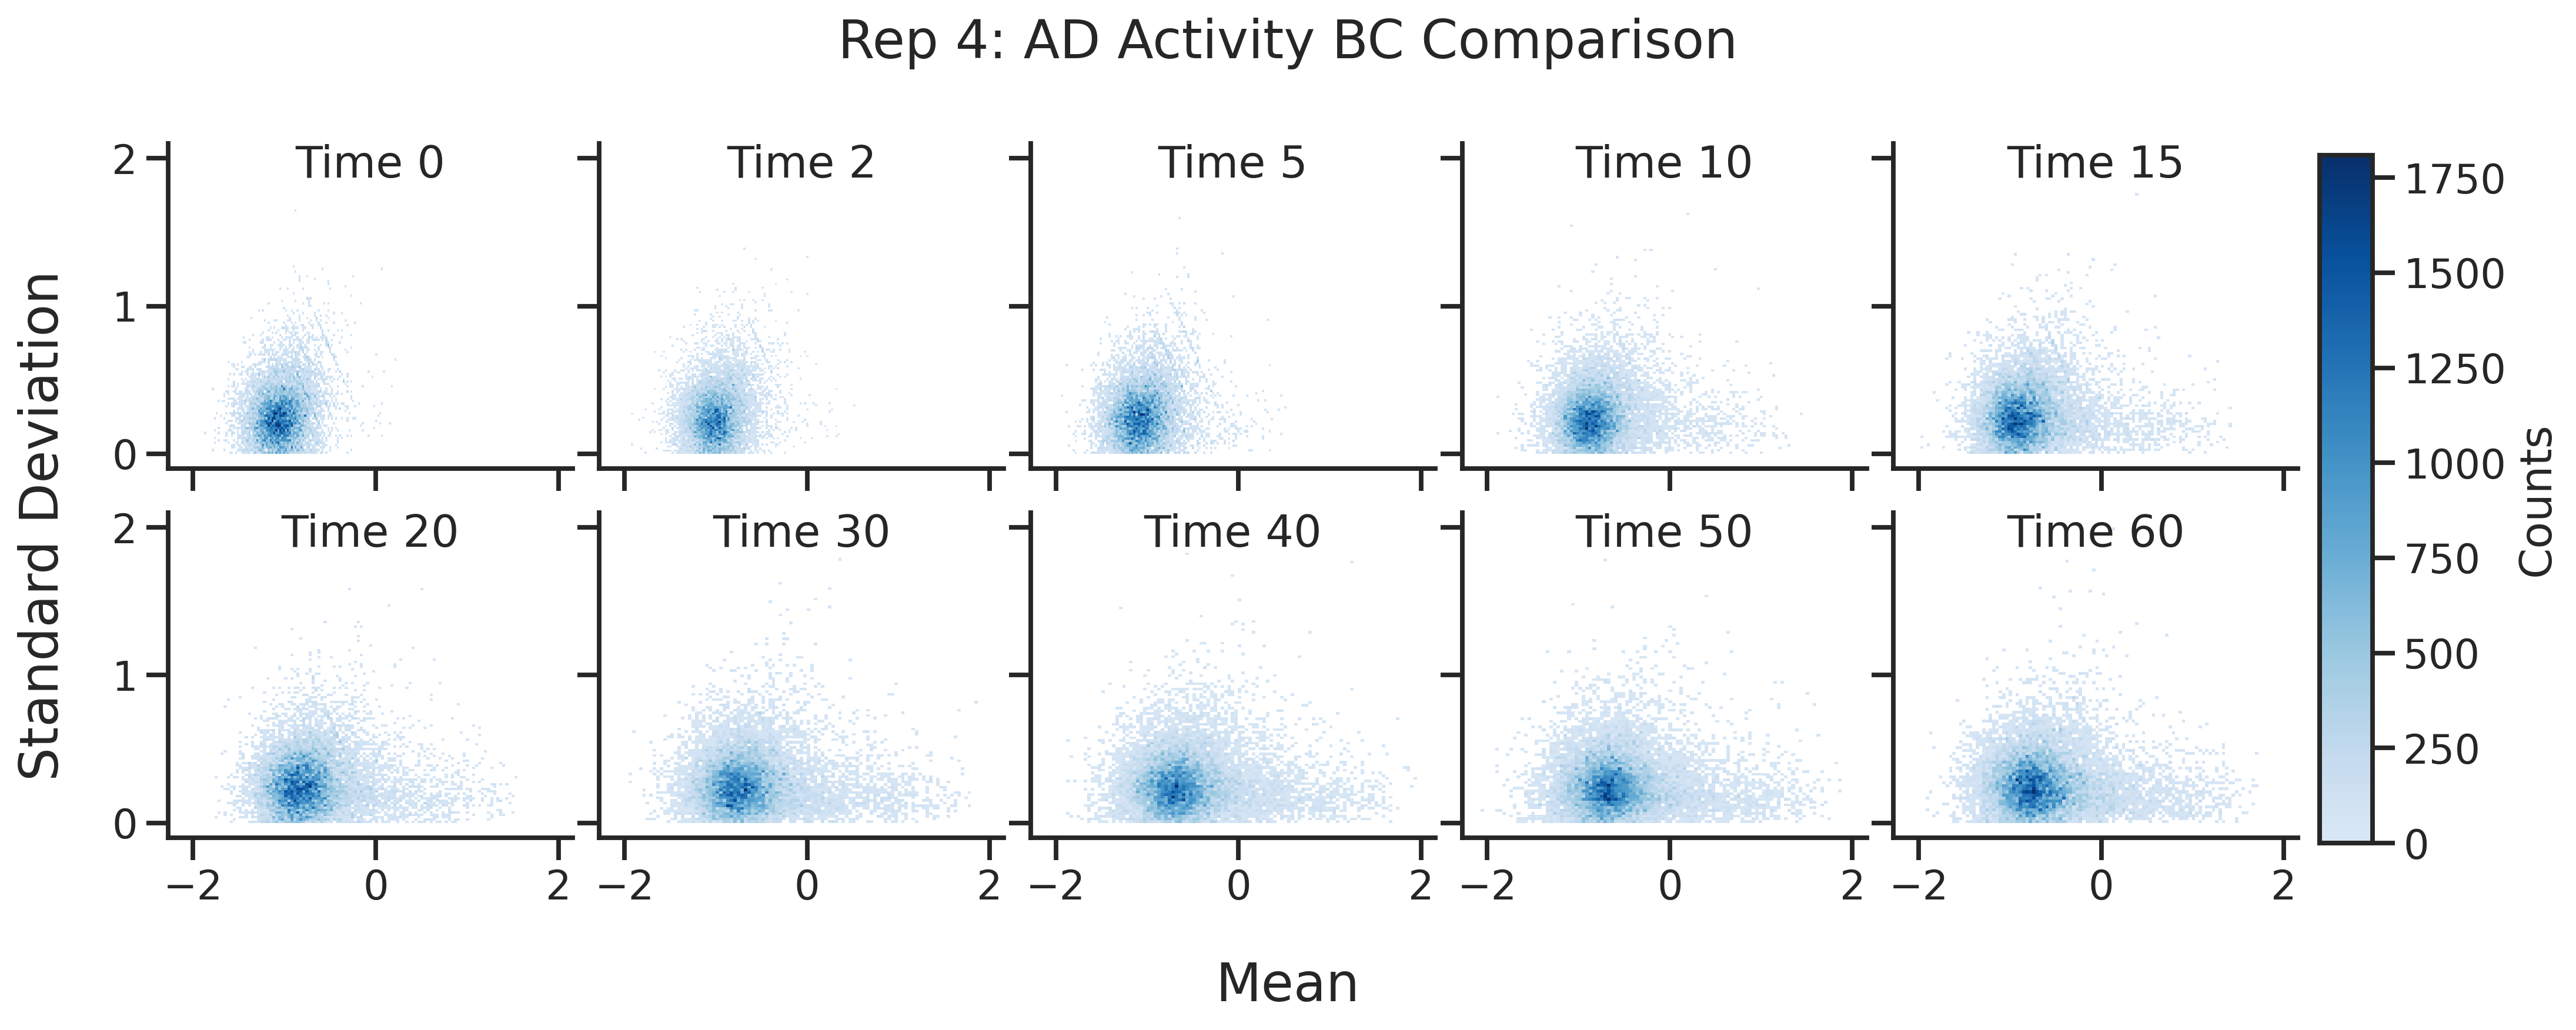

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

# Filter and log-transform
df = AD_activity_and_error_multiple_reps.copy()
print(len(df))
# df = df[(df["activity_directional_mean"] > 0) & (df["activity_directional_std"] > 0)]
print(len(df))

# df["log_mean"] = np.log10(df["activity_directional_mean"])
# df["log_std"] = np.log10(df["activity_directional_std"])

# Truncate colormap
def truncate_colormap(cmap, minval=0.25, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.15, 1.0)

# Compute global max count for all plots
counts, _, _ = np.histogram2d(df["activity_directional_mean"], df["activity_directional_std"], bins=80)
global_max = counts.max()

# Get unique reps
reps = df["rep"].unique()

for rep in reps:
    df_rep = df[df["rep"] == rep]
    times = sorted(df_rep["time"].unique())

    xmin_all = df_rep["activity_directional_mean"].min()
    xmax_all = df_rep["activity_directional_mean"].max()
    ymin_all = df_rep["activity_directional_std"].min()
    ymax_all = df_rep["activity_directional_std"].max()

    xpad = 1
    ypad = 1
    
    xmin_all -= xpad
    xmax_all += xpad
    ymin_all -= ypad
    ymax_all += ypad
    
    ncols = len(times) // 2
    fig, axes = plt.subplots(2, ncols, figsize=(3*ncols, 6), sharex=True, sharey=True, dpi = 300)
    
    if ncols == 1:
        axes = [axes]  # make iterable
    else:
        axes = axes.flatten()

    for ax, time in zip(axes, times):
        data = df_rep[df_rep["time"] == time]
        sns.histplot(
            data=data,
            x="activity_directional_mean",
            y="activity_directional_std",
            bins=100,
            cmap=cmap,
            cbar=False
        , ax=ax)
        
        ax.set_title(f"Time {time}", y = 0.85)
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    fig.suptitle(f"Rep {rep}: AD Activity BC Comparison")
    fig.supxlabel("Mean", ha='center', y = 0.04)
    fig.supylabel("Standard Deviation", va='center', rotation='vertical')
    
    # Add shared vertical colorbar on the right
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=global_max), cmap=cmap)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.89, 0.2, 0.02, 0.65])  # [left, bottom, width, height]
    fig.colorbar(sm, cax=cbar_ax, label="Counts")
    
    
    plt.tight_layout(rect=[0, 0, 0.9, 1], h_pad=0.5, w_pad=0.1)  # leave space for colorbar
    sns.despine()
    plt.show()

# UMI count threshold?

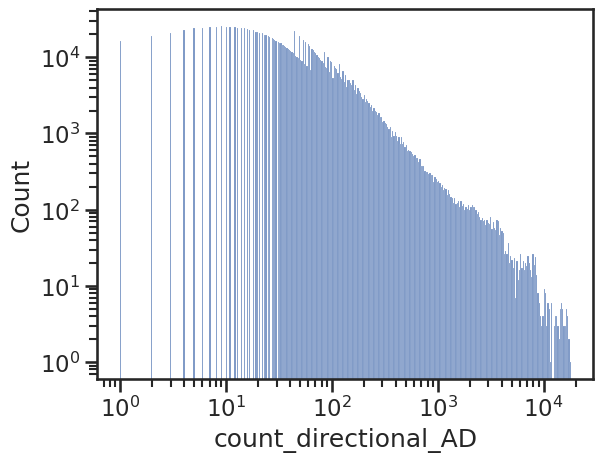

In [54]:
ax = sns.histplot(AD_RT_merged["count_directional_AD"], log_scale = (True, False))
ax.set_yscale('log')

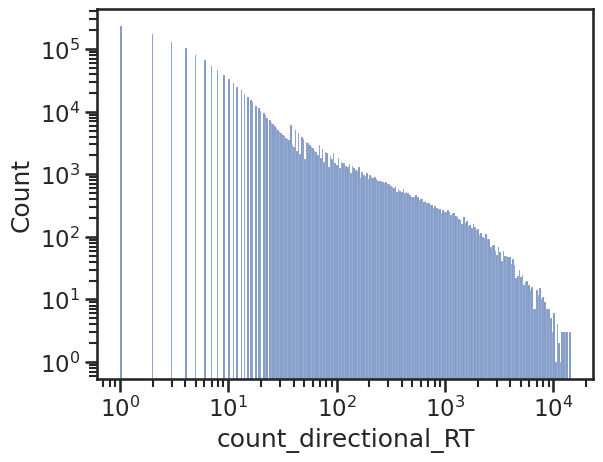

In [55]:
ax = sns.histplot(AD_RT_merged["count_directional_RT"], log_scale = (True, False))
ax.set_yscale('log')

In [56]:
AD_RT_merged

,Unnamed: 0,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361924,1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361925,1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361926,1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1361927,1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


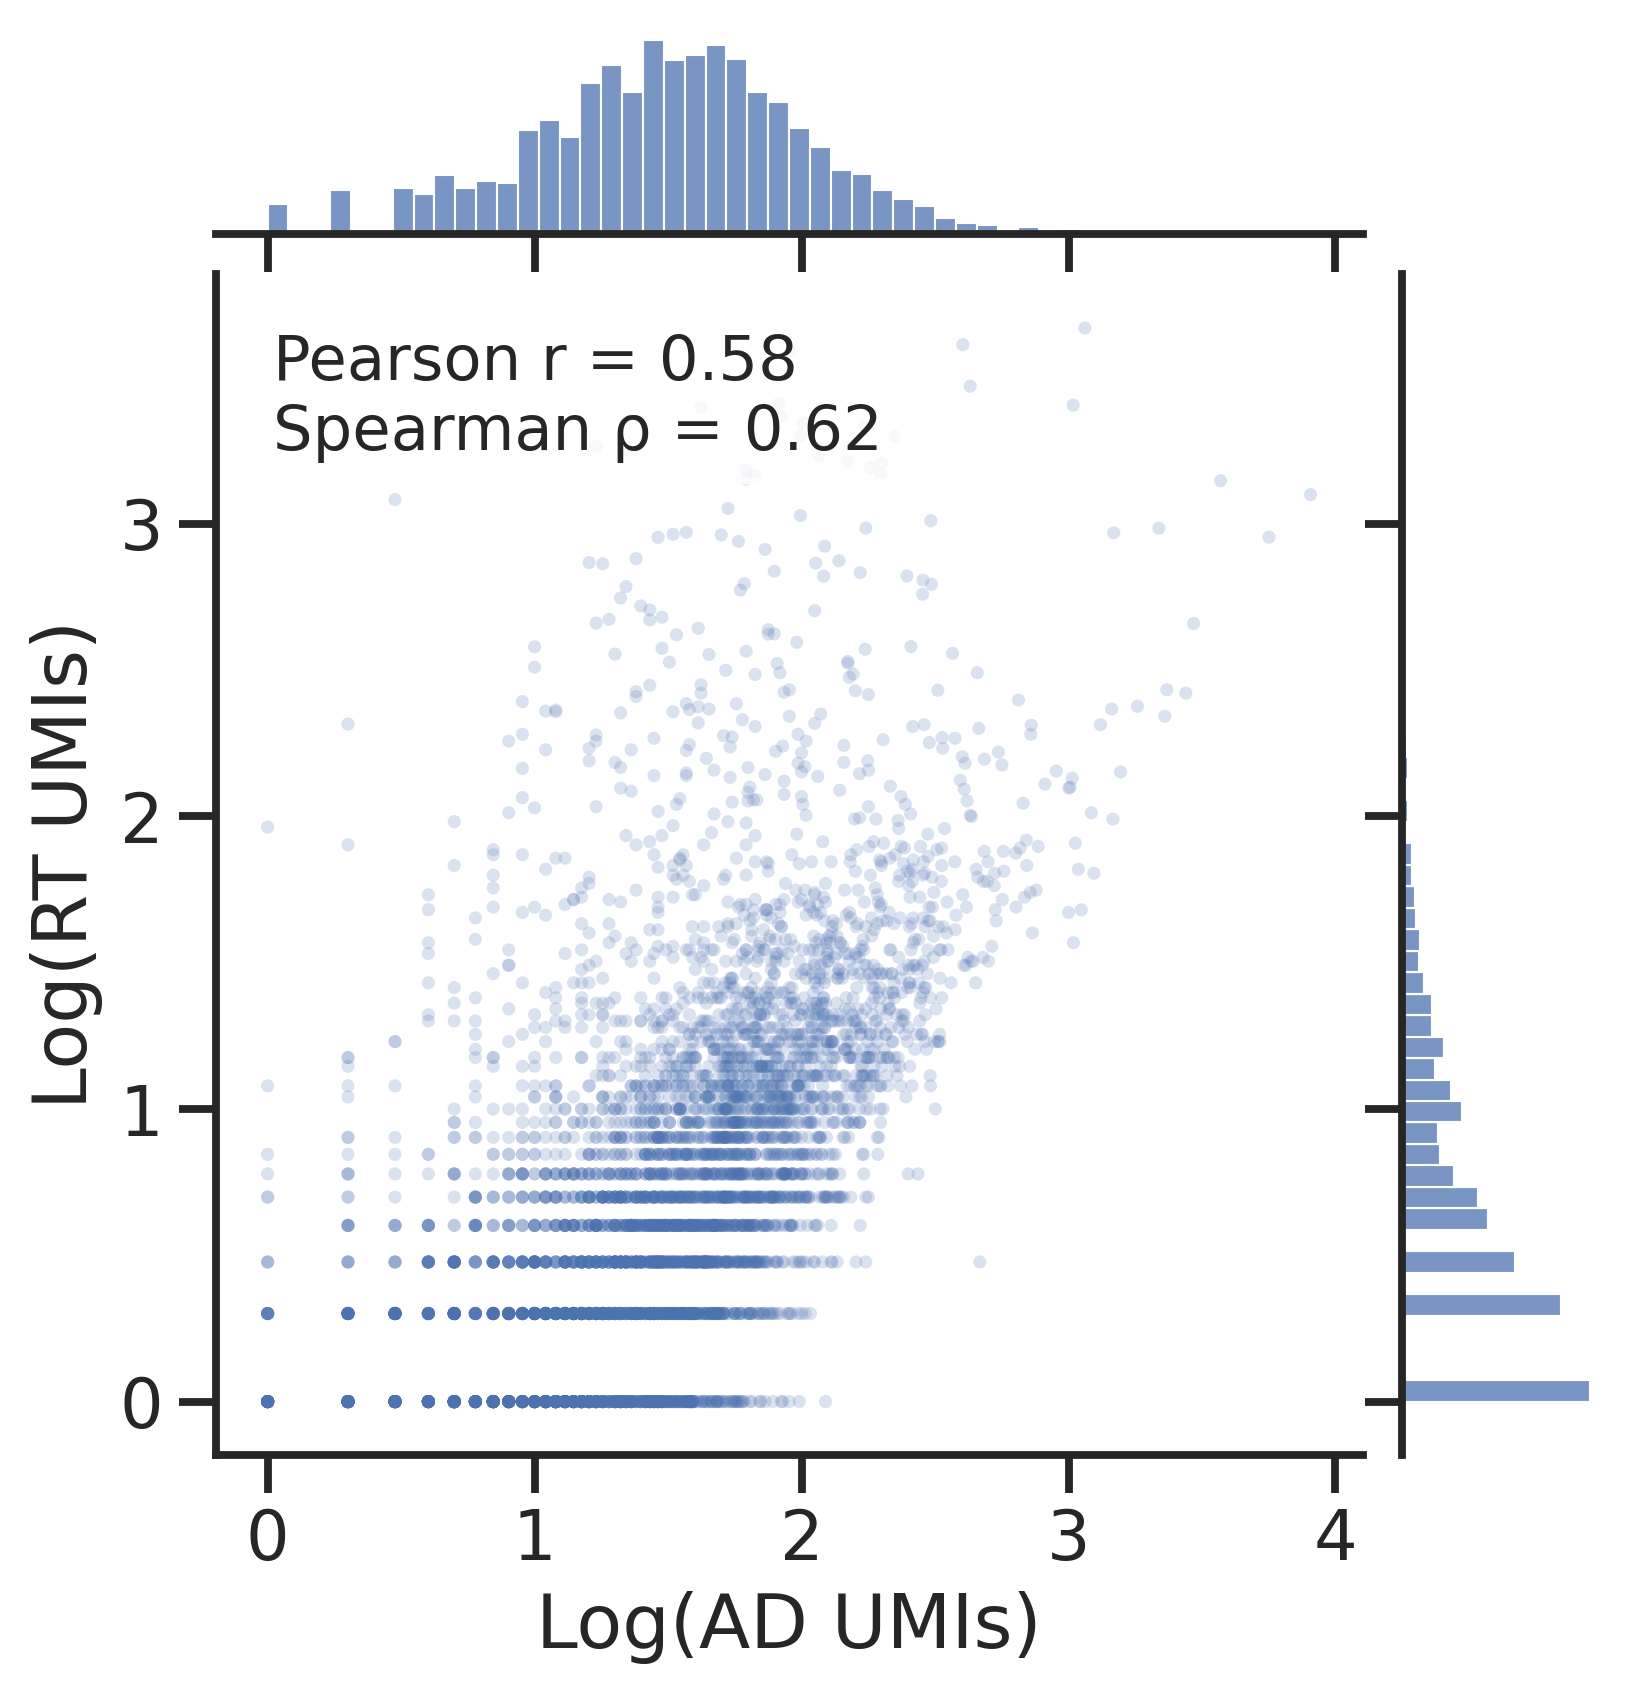

In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Add a tiny offset to avoid log(0)
df_sample = AD_RT_merged.copy()
df_sample["count_directional_AD_plot"] = np.log10(df_sample["count_directional_AD"])
df_sample["count_directional_RT_plot"] = np.log10(df_sample["count_directional_RT"])

# Sample for plotting
df_plot = df_sample.sample(5000)

# Compute correlations
pearson_corr, pearson_p = pearsonr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])
spearman_corr, spearman_p = spearmanr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])

# Jointplot with scatter + marginal histograms
g = sns.jointplot(
    data=df_plot,
    x="count_directional_AD_plot",
    y="count_directional_RT_plot",
    kind="scatter",
    alpha=0.2,
    edgecolor='none',
    s=10,
    marginal_kws=dict(bins=50, fill=True)
)
g.fig.set_dpi(300)

# Annotate correlations on the plot
textstr = f"Pearson r = {pearson_corr:.2f}\nSpearman ρ = {spearman_corr:.2f}"
g.ax_joint.text(
    0.05, 0.95, textstr,
    transform=g.ax_joint.transAxes,
    fontsize='small',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Axis labels
g.set_axis_labels("Log(AD UMIs)", "Log(RT UMIs)", fontsize='medium')

plt.show()


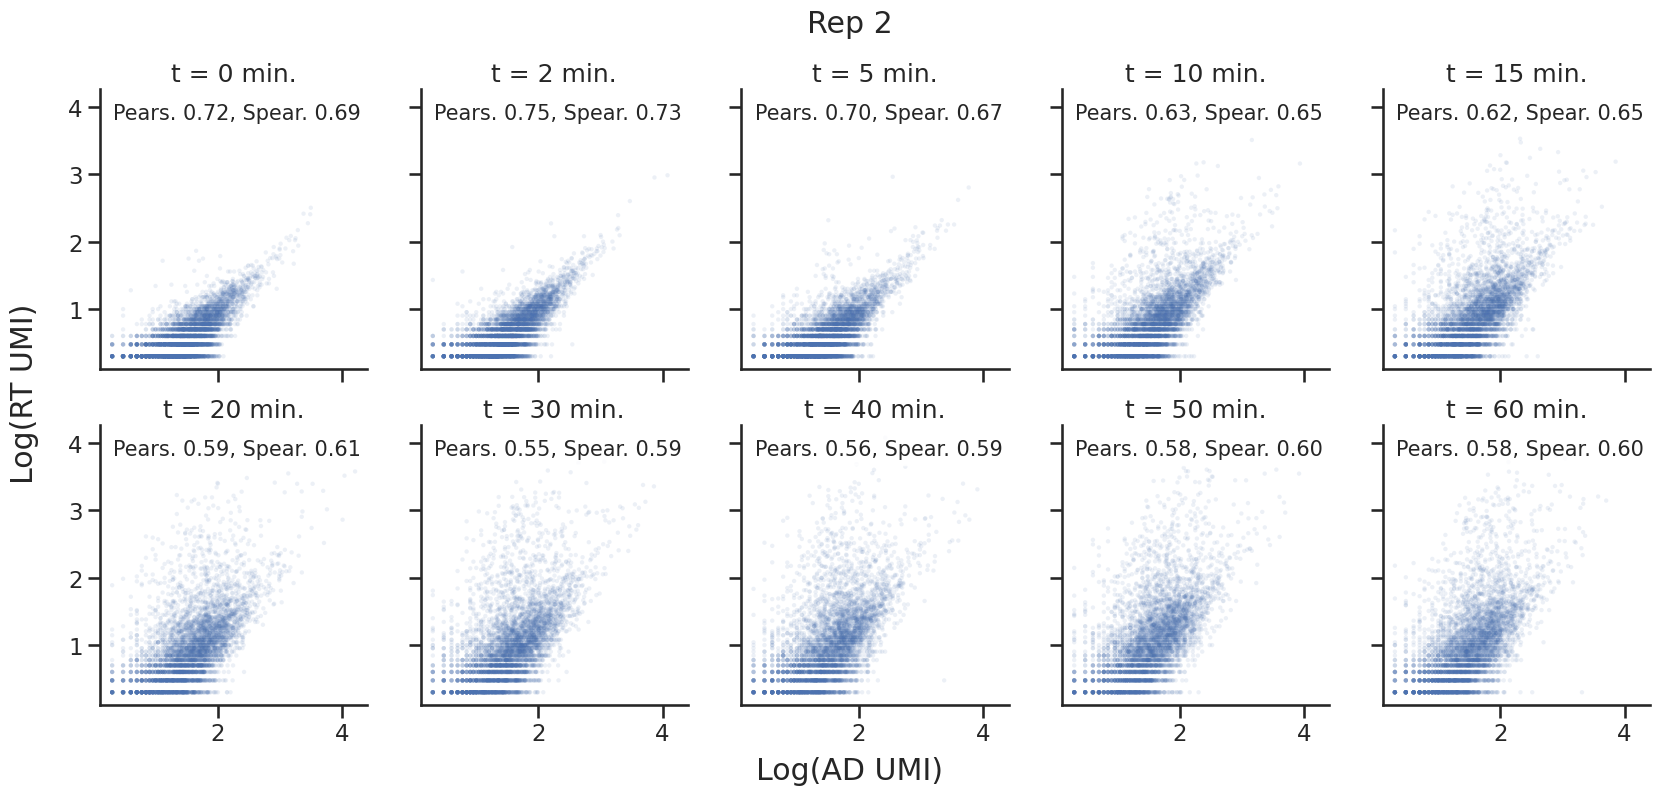

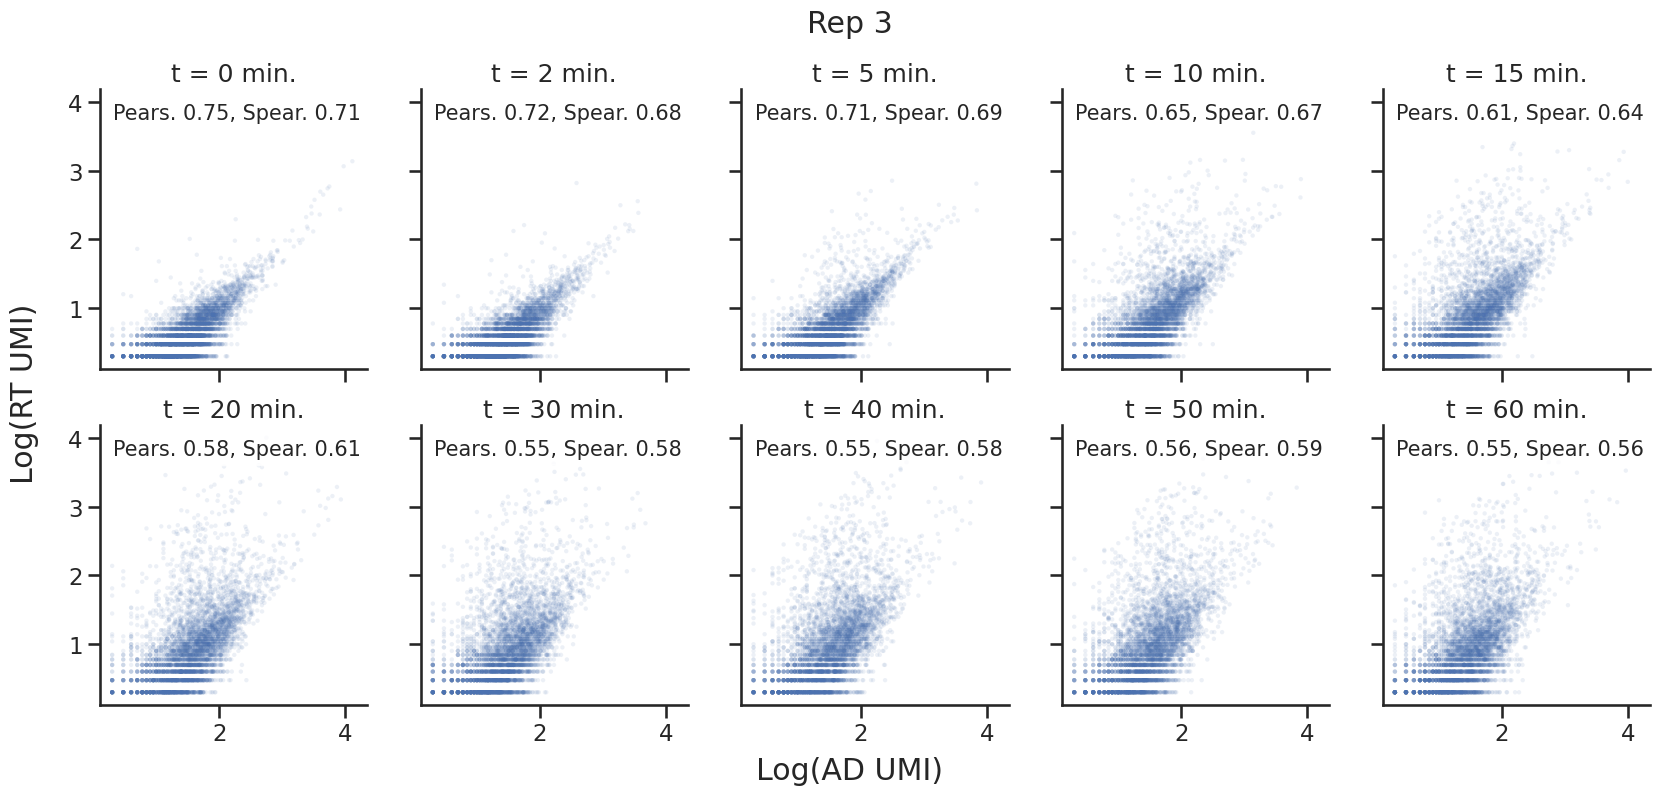

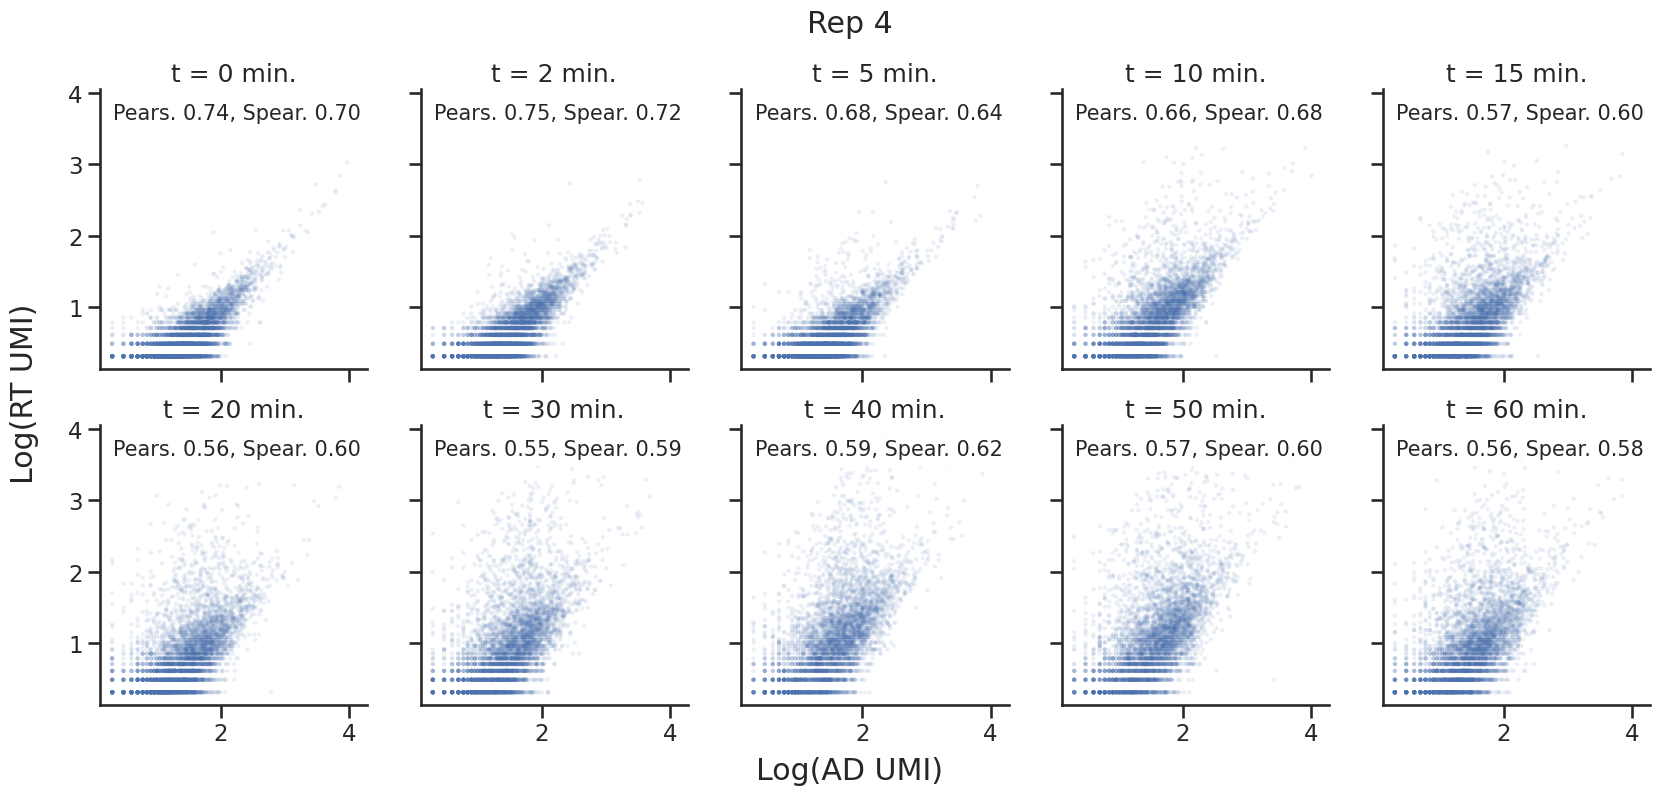

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import matplotlib.gridspec as gridspec

for rep in [2,3,4]:
    # Sort time points
    time_points = sorted(AD_RT_merged["time"].unique())
    fig,axs = plt.subplots(2,5, figsize = (20,8), sharex = True, sharey = True)
    axs = axs.flatten()
    
    
    for time, ax in zip(time_points, axs):
        # Add a tiny offset to avoid log(0)
        df_sample = AD_RT_merged.copy()
        df_sample = df_sample[df_sample["rep"] == rep]
        df_sample = df_sample[df_sample["time"] == time]
        df_sample["count_directional_AD_plot"] = np.log10(df_sample["count_directional_AD"] + 1)
        df_sample["count_directional_RT_plot"] = np.log10(df_sample["count_directional_RT"] + 1)
        
        # Sample for plotting
        df_plot = df_sample.sample(5000)
        
        # Compute correlations
        pearson_corr, pearson_p = pearsonr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])
        spearman_corr, spearman_p = spearmanr(df_plot["count_directional_AD_plot"], df_plot["count_directional_RT_plot"])
        
        # Jointplot with scatter + marginal histograms
        sns.scatterplot(
            data=df_plot,
            x="count_directional_AD_plot",
            y="count_directional_RT_plot",
            alpha=0.1,
            edgecolor='none',
            s=10, ax = ax
        )
        
        # Annotate correlations on the plot
        textstr = f"Pears. {pearson_corr:.2f}, Spear. {spearman_corr:.2f}"
        ax.text(
            0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize='small',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
        ax.set_title(f"t = {time} min.")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Axis labels
        #g.set_axis_labels("Log(AD UMIs)", "Log(RT UMIs)", fontsize='medium')
    
    fig.supxlabel("Log(AD UMI)")
    fig.supylabel("Log(RT UMI)", x = 0.08)
    fig.suptitle(f"Rep {rep}")
    sns.despine()
    plt.show()
    # plt.savefig("../../

In [ ]:
AD_RT_AD_twice = AD_RT_merged[AD_RT_merged["count_directional_AD"] > 5]
AD_RT_AD_twice

In [ ]:
AD_RT_AD_RT_twice = AD_RT_AD_twice[AD_RT_AD_twice["count_directional_RT"] > 1]
AD_RT_AD_RT_twice

In [ ]:
AD_twice_activity_and_error = AD_RT_AD_RT_twice[["AD", "activity_simple", "activity_directional", "rep", "time"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std, "count"]).reset_index()
AD_twice_activity_and_error.columns = ["AD", "rep", "time", "activity_simple_mean", "activity_simple_std", "count",
                                 "activity_directional_mean", "activity_directional_std", "rep_count"]
AD_twice_activity_and_error = AD_twice_activity_and_error.drop(columns = ["count"])
AD_twice_activity_and_error

In [ ]:
AD_twice_activity_and_error.dropna()

# What if i combine RTBCs?

In [ ]:
# Group by AD BC.. (so combining RT BC counts)
AD_RT_merged_grouped = AD_RT_merged.drop(columns = "RPTR_BC").groupby(["AD", "AD_BC", "count_simple_AD", "count_directional_AD", "rep", "time", "AD_end"]).sum().reset_index()
AD_RT_merged_grouped

In [ ]:
AD_RT_merged_grouped["activity_simple"] = np.log(AD_RT_merged_grouped["count_simple_RT"] / AD_RT_merged_grouped["count_simple_AD"])
AD_RT_merged_grouped

In [ ]:
AD_RT_merged_grouped["activity_directional"] = np.log(AD_RT_merged_grouped["count_directional_RT"] / AD_RT_merged_grouped["count_directional_AD"])
AD_RT_merged_grouped

In [ ]:
AD_grouped_activity_and_error = AD_RT_merged_grouped[["AD", "activity_simple", "activity_directional", "rep", "time"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index()
AD_grouped_activity_and_error.columns = ["AD", "rep", "time", "activity_simple_mean", "activity_simple_std",
                                 "activity_directional_mean", "activity_directional_std"]
AD_grouped_activity_and_error

In [ ]:
AD_grouped_activity_and_error_multiple_reps = AD_grouped_activity_and_error.dropna()
AD_grouped_activity_and_error_multiple_reps

In [ ]:
AD_grouped_activity_and_error_multiple_reps["activity_simple_cv"] = AD_grouped_activity_and_error_multiple_reps["activity_simple_std"] / AD_grouped_activity_and_error_multiple_reps["activity_simple_mean"]
AD_grouped_activity_and_error_multiple_reps["activity_directional_cv"] = AD_grouped_activity_and_error_multiple_reps["activity_directional_std"] / AD_grouped_activity_and_error_multiple_reps["activity_directional_mean"]
AD_grouped_activity_and_error_multiple_reps

In [ ]:
sns.histplot(data = AD_grouped_activity_and_error_multiple_reps, x = "activity_simple_cv")
sns.despine()

In [ ]:
sns.histplot(data = AD_grouped_activity_and_error_multiple_reps, x = "activity_directional_cv")
sns.despine()

In [ ]:
ax = sns.scatterplot(data = AD_grouped_activity_and_error_multiple_reps.sample(100000), x = "activity_simple_mean", y = "activity_simple_std", edgecolor = 'none', alpha = 0.002, s = 15)

plt.show()
sns.despine()

In [ ]:
ax = sns.scatterplot(data = AD_grouped_activity_and_error_multiple_reps.sample(100000), x = "activity_directional_mean", y = "activity_directional_std", edgecolor = 'none', alpha = 0.002, s = 15)


plt.show()
sns.despine()